In [267]:
# ============================================================
# 01. SETUP & IMPORT LIBRARY
# Forecasting ISPU - Random Forest
# ============================================================

import os
import warnings

import numpy as np
import pandas as pd


from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")

# Reproducibility
RANDOM_STATE = 42

print("Setup berhasil.")
print("Random State:", RANDOM_STATE)
print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)

Setup berhasil.
Random State: 42
Pandas: 3.0.6
NumPy: 2.5.3


In [268]:
# ============================================================
# 02. LOAD DATASET
# ============================================================

DATA_PATH = "../data/raw/merged_1_datetime.csv"

df = pd.read_csv(
    DATA_PATH,
    parse_dates=["DATETIME"],
    decimal=","
)

print("Dataset berhasil dimuat.")
print("Shape:", df.shape)
print("Periode:", df["DATETIME"].min(), "→", df["DATETIME"].max())

display(df.head())

Dataset berhasil dimuat.
Shape: (324988, 12)
Periode: 2026-07-01 00:00:01 → 2026-09-21 17:40:02


,DATETIME,NO2,SO2,PM25,PM10,CO,O3,TMP,RAIN,HUM,WS,WD
0,2026-07-01 00:00:01,50.64,3.46,6.48,12.80,395.07,3.77,32.76,0.0,73.40,1.52,134
1,2026-07-01 00:00:02,16.43,0.00,40.08,73.72,725.05,13.55,32.72,0.0,72.14,0.05,50
2,2026-07-01 00:00:02,16.43,0.00,40.08,73.72,725.05,13.55,32.28,0.0,72.89,0.76,225
3,2026-07-01 00:00:02,16.43,0.00,40.08,73.72,725.05,13.55,32.73,0.0,65.19,3.26,167
4,2026-07-01 00:00:02,18.87,0.00,18.32,41.00,423.55,55.66,32.72,0.0,72.14,0.05,50


In [269]:
# ============================================================
# 03. DATA UNDERSTANDING
# ============================================================

print("=== INFORMASI DATASET ===")
print(df.info())

print("\n=== JUMLAH MISSING VALUE ===")
display(df.isna().sum().to_frame("Missing"))

print("\n=== JUMLAH DUPLIKAT BARIS ===")
print(df.duplicated().sum())

print("\n=== JUMLAH TIMESTAMP UNIK ===")
print(df["DATETIME"].nunique())

print("\n=== KOLOM DATASET ===")
print(df.columns.tolist())

=== INFORMASI DATASET ===
<class 'pandas.DataFrame'>
RangeIndex: 324988 entries, 0 to 324987
Data columns (total 12 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   DATETIME  324988 non-null  datetime64[us]
 1   NO2       324988 non-null  float64       
 2   SO2       324988 non-null  float64       
 3   PM25      324988 non-null  float64       
 4   PM10      324988 non-null  float64       
 5   CO        324988 non-null  float64       
 6   O3        324988 non-null  float64       
 7   TMP       324988 non-null  float64       
 8   RAIN      324988 non-null  float64       
 9   HUM       324988 non-null  float64       
 10  WS        324988 non-null  float64       
 11  WD        324988 non-null  int64         
dtypes: datetime64[us](1), float64(10), int64(1)
memory usage: 29.8 MB
None

=== JUMLAH MISSING VALUE ===


,Missing
DATETIME,0
NO2,0
SO2,0
PM25,0
PM10,0
CO,0
O3,0
TMP,0
RAIN,0
HUM,0



=== JUMLAH DUPLIKAT BARIS ===
0

=== JUMLAH TIMESTAMP UNIK ===
46333

=== KOLOM DATASET ===
['DATETIME', 'NO2', 'SO2', 'PM25', 'PM10', 'CO', 'O3', 'TMP', 'RAIN', 'HUM', 'WS', 'WD']


In [270]:
# ============================================================
# 04. MEMBUAT TIMESTAMP 5 MENIT
# ============================================================

df["DATETIME_5MIN"] = df["DATETIME"].dt.floor("5min")

print("Timestamp 5 menit berhasil dibuat.")

print("\nJumlah timestamp unik sebelum agregasi:",
      df["DATETIME"].nunique())

print("Jumlah timestamp 5 menit:",
      df["DATETIME_5MIN"].nunique())

display(
    df[["DATETIME", "DATETIME_5MIN"]].head(10)
)

Timestamp 5 menit berhasil dibuat.

Jumlah timestamp unik sebelum agregasi: 46333
Jumlah timestamp 5 menit: 23533


,DATETIME,DATETIME_5MIN
0,2026-07-01 00:00:01,2026-07-01
1,2026-07-01 00:00:02,2026-07-01
2,2026-07-01 00:00:02,2026-07-01
3,2026-07-01 00:00:02,2026-07-01
4,2026-07-01 00:00:02,2026-07-01
5,2026-07-01 00:00:02,2026-07-01
6,2026-07-01 00:00:02,2026-07-01
7,2026-07-01 00:00:02,2026-07-01
8,2026-07-01 00:00:02,2026-07-01
9,2026-07-01 00:00:02,2026-07-01


In [271]:
# ============================================================
# 05. AGREGASI DATA KE INTERVAL 5 MENIT
# ============================================================

df_5min = (
    df.groupby("DATETIME_5MIN")
    .agg({
        "NO2": "mean",
        "SO2": "mean",
        "PM25": "mean",
        "PM10": "mean",
        "CO": "mean",
        "O3": "mean",
        "TMP": "mean",
        "RAIN": "mean",
        "HUM": "mean",
        "WS": "mean",
        "WD": "mean"
    })
    .reset_index()
)

print("Agregasi 5 menit selesai.")
print("Shape:", df_5min.shape)
print(
    "Periode:",
    df_5min["DATETIME_5MIN"].min(),
    "→",
    df_5min["DATETIME_5MIN"].max()
)

print("\nJumlah missing value:")
display(df_5min.isna().sum().to_frame("Missing"))

display(df_5min.head())

Agregasi 5 menit selesai.
Shape: (23533, 12)
Periode: 2026-07-01 00:00:00 → 2026-09-21 17:40:00

Jumlah missing value:


,Missing
DATETIME_5MIN,0
NO2,0
SO2,0
PM25,0
PM10,0
CO,0
O3,0
TMP,0
RAIN,0
HUM,0


,DATETIME_5MIN,NO2,SO2,PM25,PM10,CO,O3,TMP,RAIN,HUM,WS,WD
0,2026-07-01 00:00:00,14.607692,1.143077,20.727692,42.608462,480.842308,23.147692,32.590769,0.0,70.329231,1.369231,146.307692
1,2026-07-01 00:05:00,18.420769,1.151538,22.643077,44.743846,512.608462,18.884615,32.315385,0.0,72.180769,1.618462,139.615385
2,2026-07-01 00:10:00,18.908462,1.922308,17.232308,36.014615,456.098462,23.806154,32.174615,0.0,72.046923,2.154615,173.538462
3,2026-07-01 00:20:00,14.212353,2.244706,17.289412,35.922353,445.670588,19.367059,31.672941,0.0,73.311176,1.960588,143.764706
4,2026-07-01 00:25:00,13.285000,1.722500,17.527500,36.920000,438.810000,16.317500,31.040000,0.0,75.240000,0.000000,0.000000


In [272]:
# ============================================================
# 06. CEK GAP INTERVAL 5 MENIT
# ============================================================

expected_5min = pd.date_range(
    start=df_5min["DATETIME_5MIN"].min(),
    end=df_5min["DATETIME_5MIN"].max(),
    freq="5min"
)

actual_5min = pd.DatetimeIndex(
    df_5min["DATETIME_5MIN"]
)

missing_5min = expected_5min.difference(actual_5min)

print("=== CEK INTERVAL 5 MENIT ===")
print("Interval yang seharusnya :", len(expected_5min))
print("Interval yang tersedia   :", len(actual_5min))
print("Interval yang hilang     :", len(missing_5min))

print("\nContoh interval yang hilang:")
display(pd.DataFrame({
    "Missing_5MIN": missing_5min[:20]
}))

=== CEK INTERVAL 5 MENIT ===
Interval yang seharusnya : 23829
Interval yang tersedia   : 23533
Interval yang hilang     : 296

Contoh interval yang hilang:


,Missing_5MIN
0,2026-07-01 00:15:00
1,2026-07-01 00:40:00
2,2026-07-01 04:45:00
3,2026-07-01 04:55:00
4,2026-07-01 05:10:00
5,2026-07-01 05:55:00
6,2026-07-01 06:10:00
7,2026-07-01 06:30:00
8,2026-07-01 06:35:00
9,2026-07-01 07:00:00


In [273]:
# ============================================================
# 07. ANALISIS PANJANG GAP 5 MENIT
# ============================================================

full_5min_df = pd.DataFrame({
    "DATETIME_5MIN": expected_5min
})

full_5min_df["is_missing"] = ~full_5min_df["DATETIME_5MIN"].isin(
    actual_5min
)

# Kelompokkan interval missing yang berurutan
full_5min_df["gap_group"] = (
    full_5min_df["is_missing"]
    .ne(full_5min_df["is_missing"].shift())
    .cumsum()
)

gap_summary = (
    full_5min_df[full_5min_df["is_missing"]]
    .groupby("gap_group")
    .agg(
        gap_start=("DATETIME_5MIN", "min"),
        gap_end=("DATETIME_5MIN", "max"),
        missing_intervals=("DATETIME_5MIN", "count")
    )
    .reset_index(drop=True)
)

gap_summary["gap_minutes"] = (
    gap_summary["missing_intervals"] * 5
)

print("Jumlah kelompok gap:", len(gap_summary))

print("\n=== DISTRIBUSI PANJANG GAP ===")

display(
    gap_summary["missing_intervals"]
    .value_counts()
    .sort_index()
    .rename_axis("Missing_Intervals")
    .reset_index(name="Jumlah_Gap")
)

print("\n=== GAP TERPANJANG ===")

display(
    gap_summary
    .sort_values("missing_intervals", ascending=False)
    .head(10)
)

Jumlah kelompok gap: 212

=== DISTRIBUSI PANJANG GAP ===


,Missing_Intervals,Jumlah_Gap
0,1,186
1,2,14
2,3,9
3,5,1
4,6,1
5,44,1



=== GAP TERPANJANG ===


,gap_start,gap_end,missing_intervals,gap_minutes
96,2026-08-05 15:50:00,2026-08-05 19:25:00,44,220
204,2026-09-16 15:15:00,2026-09-16 15:40:00,6,30
25,2026-07-02 07:15:00,2026-07-02 07:35:00,5,25
81,2026-07-23 17:55:00,2026-07-23 18:05:00,3,15
205,2026-09-16 15:50:00,2026-09-16 16:00:00,3,15
166,2026-09-09 08:20:00,2026-09-09 08:30:00,3,15
201,2026-09-16 14:10:00,2026-09-16 14:20:00,3,15
203,2026-09-16 14:55:00,2026-09-16 15:05:00,3,15
200,2026-09-16 13:50:00,2026-09-16 14:00:00,3,15
207,2026-09-16 16:25:00,2026-09-16 16:35:00,3,15


In [274]:
# ============================================================
# 08. INTERPOLASI GAP PENDEK
# ============================================================

# Buat timeline 5 menit lengkap
full_5min = pd.date_range(
    start=df_5min["DATETIME_5MIN"].min(),
    end=df_5min["DATETIME_5MIN"].max(),
    freq="5min"
)

# Reindex agar interval yang hilang menjadi NaN
df_5min_full = (
    df_5min
    .set_index("DATETIME_5MIN")
    .reindex(full_5min)
)

numeric_cols = [
    "NO2", "SO2", "PM25", "PM10", "CO", "O3",
    "TMP", "RAIN", "HUM", "WS", "WD"
]

missing_before = df_5min_full[numeric_cols].isna().sum()

# Interpolasi berbasis waktu, maksimal 3 interval = 15 menit
df_5min_full[numeric_cols] = (
    df_5min_full[numeric_cols]
    .interpolate(
        method="time",
        limit=3,
        limit_area="inside"
    )
)

missing_after = df_5min_full[numeric_cols].isna().sum()

print("=== HASIL INTERPOLASI ===")

print("\nMissing sebelum interpolasi:")
display(missing_before.to_frame("Missing_Before"))

print("\nMissing setelah interpolasi:")
display(missing_after.to_frame("Missing_After"))

print("\nShape:", df_5min_full.shape)

=== HASIL INTERPOLASI ===

Missing sebelum interpolasi:


,Missing_Before
NO2,296
SO2,296
PM25,296
PM10,296
CO,296
O3,296
TMP,296
RAIN,296
HUM,296
WS,296



Missing setelah interpolasi:


,Missing_After
NO2,46
SO2,46
PM25,46
PM10,46
CO,46
O3,46
TMP,46
RAIN,46
HUM,46
WS,46



Shape: (23829, 11)


In [275]:
# ============================================================
# 09. AGREGASI DATA KE INTERVAL 1 JAM
# ============================================================

df_hourly = (
    df_5min_full
    .resample("1h")
    .agg({
        "NO2": "mean",
        "SO2": "mean",
        "PM25": "mean",
        "PM10": "mean",
        "CO": "mean",
        "O3": "mean",
        "TMP": "mean",
        "RAIN": "mean",
        "HUM": "mean",
        "WS": "mean",
        "WD": "mean"
    })
)

print("=== HASIL AGREGASI HOURLY ===")
print("Shape:", df_hourly.shape)

print(
    "Periode:",
    df_hourly.index.min(),
    "→",
    df_hourly.index.max()
)

print("\nJumlah missing per variabel:")
display(
    df_hourly.isna().sum().to_frame("Missing")
)

print("\nJumlah baris yang memiliki missing:")
print(df_hourly.isna().any(axis=1).sum())

display(df_hourly.head())

=== HASIL AGREGASI HOURLY ===
Shape: (1986, 11)
Periode: 2026-07-01 00:00:00 → 2026-09-21 17:00:00

Jumlah missing per variabel:


,Missing
NO2,2
SO2,2
PM25,2
PM10,2
CO,2
O3,2
TMP,2
RAIN,2
HUM,2
WS,2



Jumlah baris yang memiliki missing:
2


,NO2,SO2,PM25,PM10,CO,O3,TMP,RAIN,HUM,WS,WD
2026-07-01 00:00:00,17.096474,1.569536,21.255265,43.898704,465.064224,21.457800,31.756087,0.0,73.586702,1.463298,141.083861
2026-07-01 01:00:00,20.026875,1.206058,23.089072,47.641170,448.993323,21.626055,30.734312,0.0,76.818837,1.423762,138.170814
2026-07-01 02:00:00,23.489118,1.292720,18.582015,40.324981,409.513921,19.704114,29.748591,0.0,78.965175,1.209339,140.101735
2026-07-01 03:00:00,30.437735,1.394721,15.844247,35.921184,401.504320,15.859188,29.124881,0.0,81.594595,1.079078,134.229871
2026-07-01 04:00:00,30.034439,1.212319,16.771483,38.846235,396.398652,15.006194,28.745444,0.0,83.300049,1.059880,128.262500


In [276]:
# ============================================================
# 10. CEK MISSING HOURLY
# ============================================================

missing_hourly = df_hourly[
    df_hourly.isna().all(axis=1)
]

print("Jumlah hourly yang seluruhnya missing:",
      len(missing_hourly))

print("\nTimestamp yang missing:")
display(missing_hourly)

print("\nJumlah missing per timestamp:")
display(
    df_hourly.isna().sum(axis=1)
    .loc[lambda x: x > 0]
    .to_frame("Missing_Columns")
)

Jumlah hourly yang seluruhnya missing: 2

Timestamp yang missing:


,NO2,SO2,PM25,PM10,CO,O3,TMP,RAIN,HUM,WS,WD
2026-08-05 17:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-08-05 18:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Jumlah missing per timestamp:


,Missing_Columns
2026-08-05 17:00:00,11
2026-08-05 18:00:00,11


In [277]:
# ============================================================
# 11. FEATURE ENGINEERING
# ============================================================

pollutant_cols = [
    "PM25",
    "PM10",
    "CO",
    "O3",
    "SO2",
    "NO2"
]

df_model = df_hourly.copy()


# ------------------------------------------------------------
# 1. LAG FEATURES
# ------------------------------------------------------------

lag_hours = [1, 2, 3, 6, 24]

for col in pollutant_cols:
    for lag in lag_hours:
        df_model[f"{col}_lag_{lag}"] = (
            df_model[col].shift(lag)
        )


# ------------------------------------------------------------
# 2. ROLLING MEAN
# ------------------------------------------------------------

rolling_windows = [3, 6]

for col in pollutant_cols:
    for window in rolling_windows:
        df_model[f"{col}_roll_mean_{window}"] = (
            df_model[col].rolling(window=window).mean()
        )


# ------------------------------------------------------------
# 3. WIND DIRECTION → SIN/COS
# ------------------------------------------------------------

df_model["WD_sin"] = np.sin(
    np.deg2rad(df_model["WD"])
)

df_model["WD_cos"] = np.cos(
    np.deg2rad(df_model["WD"])
)


# ------------------------------------------------------------
# 4. TIME FEATURES
# ------------------------------------------------------------

df_model["hour"] = df_model.index.hour

df_model["day_of_week"] = (
    df_model.index.dayofweek
)

df_model["hour_sin"] = np.sin(
    2 * np.pi * df_model["hour"] / 24
)

df_model["hour_cos"] = np.cos(
    2 * np.pi * df_model["hour"] / 24
)


# ------------------------------------------------------------
# 5. DEFINE MODEL FEATURES
# ------------------------------------------------------------
# WD tetap disimpan di df_model untuk referensi,
# tetapi tidak digunakan sebagai input Random Forest.
# Sebagai gantinya digunakan WD_sin dan WD_cos.

feature_cols = [
    col for col in df_model.columns
    if col != "WD"
]


# ------------------------------------------------------------
# CHECK
# ------------------------------------------------------------

print("=== FEATURE ENGINEERING SELESAI ===")

print("Shape df_model:", df_model.shape)
print("Jumlah seluruh kolom:", len(df_model.columns))

print("\n=== MODEL FEATURES ===")
print("Jumlah fitur model:", len(feature_cols))

print("\nWD masuk feature?", "WD" in feature_cols)
print("WD_sin masuk?", "WD_sin" in feature_cols)
print("WD_cos masuk?", "WD_cos" in feature_cols)

print("\nDaftar fitur:")
print(feature_cols)

display(df_model.head())

=== FEATURE ENGINEERING SELESAI ===
Shape df_model: (1986, 59)
Jumlah seluruh kolom: 59

=== MODEL FEATURES ===
Jumlah fitur model: 58

WD masuk feature? False
WD_sin masuk? True
WD_cos masuk? True

Daftar fitur:
['NO2', 'SO2', 'PM25', 'PM10', 'CO', 'O3', 'TMP', 'RAIN', 'HUM', 'WS', 'PM25_lag_1', 'PM25_lag_2', 'PM25_lag_3', 'PM25_lag_6', 'PM25_lag_24', 'PM10_lag_1', 'PM10_lag_2', 'PM10_lag_3', 'PM10_lag_6', 'PM10_lag_24', 'CO_lag_1', 'CO_lag_2', 'CO_lag_3', 'CO_lag_6', 'CO_lag_24', 'O3_lag_1', 'O3_lag_2', 'O3_lag_3', 'O3_lag_6', 'O3_lag_24', 'SO2_lag_1', 'SO2_lag_2', 'SO2_lag_3', 'SO2_lag_6', 'SO2_lag_24', 'NO2_lag_1', 'NO2_lag_2', 'NO2_lag_3', 'NO2_lag_6', 'NO2_lag_24', 'PM25_roll_mean_3', 'PM25_roll_mean_6', 'PM10_roll_mean_3', 'PM10_roll_mean_6', 'CO_roll_mean_3', 'CO_roll_mean_6', 'O3_roll_mean_3', 'O3_roll_mean_6', 'SO2_roll_mean_3', 'SO2_roll_mean_6', 'NO2_roll_mean_3', 'NO2_roll_mean_6', 'WD_sin', 'WD_cos', 'hour', 'day_of_week', 'hour_sin', 'hour_cos']


,NO2,SO2,PM25,PM10,CO,O3,TMP,RAIN,HUM,WS,...,SO2_roll_mean_3,SO2_roll_mean_6,NO2_roll_mean_3,NO2_roll_mean_6,WD_sin,WD_cos,hour,day_of_week,hour_sin,hour_cos
2026-07-01 00:00:00,17.096474,1.569536,21.255265,43.898704,465.064224,21.457800,31.756087,0.0,73.586702,1.463298,...,NaN,NaN,NaN,NaN,0.628182,-0.778066,0,2,0.000000,1.000000
2026-07-01 01:00:00,20.026875,1.206058,23.089072,47.641170,448.993323,21.626055,30.734312,0.0,76.818837,1.423762,...,NaN,NaN,NaN,NaN,0.666912,-0.745136,1,2,0.258819,0.965926
2026-07-01 02:00:00,23.489118,1.292720,18.582015,40.324981,409.513921,19.704114,29.748591,0.0,78.965175,1.209339,...,1.356105,NaN,20.204156,NaN,0.641426,-0.767185,2,2,0.500000,0.866025
2026-07-01 03:00:00,30.437735,1.394721,15.844247,35.921184,401.504320,15.859188,29.124881,0.0,81.594595,1.079078,...,1.297833,NaN,24.651243,NaN,0.716547,-0.697539,3,2,0.707107,0.707107
2026-07-01 04:00:00,30.034439,1.212319,16.771483,38.846235,396.398652,15.006194,28.745444,0.0,83.300049,1.059880,...,1.299920,NaN,27.987097,NaN,0.785182,-0.619265,4,2,0.866025,0.500000


In [278]:
# ============================================================
# 12. MENENTUKAN FITUR FINAL
# ============================================================

# WD mentah tidak digunakan sebagai fitur.
# WD direpresentasikan menggunakan WD_sin dan WD_cos.

feature_cols = [
    "NO2",
    "SO2",
    "PM25",
    "PM10",
    "CO",
    "O3",
    "TMP",
    "RAIN",
    "HUM",
    "WS",

    # Lag features
    "PM25_lag_1",
    "PM25_lag_2",
    "PM25_lag_3",
    "PM25_lag_6",
    "PM25_lag_24",

    "PM10_lag_1",
    "PM10_lag_2",
    "PM10_lag_3",
    "PM10_lag_6",
    "PM10_lag_24",

    "CO_lag_1",
    "CO_lag_2",
    "CO_lag_3",
    "CO_lag_6",
    "CO_lag_24",

    "O3_lag_1",
    "O3_lag_2",
    "O3_lag_3",
    "O3_lag_6",
    "O3_lag_24",

    "SO2_lag_1",
    "SO2_lag_2",
    "SO2_lag_3",
    "SO2_lag_6",
    "SO2_lag_24",

    "NO2_lag_1",
    "NO2_lag_2",
    "NO2_lag_3",
    "NO2_lag_6",
    "NO2_lag_24",

    # Rolling mean
    "PM25_roll_mean_3",
    "PM25_roll_mean_6",
    "PM10_roll_mean_3",
    "PM10_roll_mean_6",
    "CO_roll_mean_3",
    "CO_roll_mean_6",
    "O3_roll_mean_3",
    "O3_roll_mean_6",
    "SO2_roll_mean_3",
    "SO2_roll_mean_6",
    "NO2_roll_mean_3",
    "NO2_roll_mean_6",

    # Wind direction
    "WD_sin",
    "WD_cos",

    # Time features
    "hour",
    "day_of_week",
    "hour_sin",
    "hour_cos"
]

print("=== FINAL FEATURE SET ===")
print("Jumlah fitur:", len(feature_cols))

print("\nWD masuk feature?", "WD" in feature_cols)
print("WD_sin masuk?", "WD_sin" in feature_cols)
print("WD_cos masuk?", "WD_cos" in feature_cols)

print("\nDaftar fitur:")
for i, col in enumerate(feature_cols, start=1):
    print(f"{i:2d}. {col}")

=== FINAL FEATURE SET ===
Jumlah fitur: 58

WD masuk feature? False
WD_sin masuk? True
WD_cos masuk? True

Daftar fitur:
 1. NO2
 2. SO2
 3. PM25
 4. PM10
 5. CO
 6. O3
 7. TMP
 8. RAIN
 9. HUM
10. WS
11. PM25_lag_1
12. PM25_lag_2
13. PM25_lag_3
14. PM25_lag_6
15. PM25_lag_24
16. PM10_lag_1
17. PM10_lag_2
18. PM10_lag_3
19. PM10_lag_6
20. PM10_lag_24
21. CO_lag_1
22. CO_lag_2
23. CO_lag_3
24. CO_lag_6
25. CO_lag_24
26. O3_lag_1
27. O3_lag_2
28. O3_lag_3
29. O3_lag_6
30. O3_lag_24
31. SO2_lag_1
32. SO2_lag_2
33. SO2_lag_3
34. SO2_lag_6
35. SO2_lag_24
36. NO2_lag_1
37. NO2_lag_2
38. NO2_lag_3
39. NO2_lag_6
40. NO2_lag_24
41. PM25_roll_mean_3
42. PM25_roll_mean_6
43. PM10_roll_mean_3
44. PM10_roll_mean_6
45. CO_roll_mean_3
46. CO_roll_mean_6
47. O3_roll_mean_3
48. O3_roll_mean_6
49. SO2_roll_mean_3
50. SO2_roll_mean_6
51. NO2_roll_mean_3
52. NO2_roll_mean_6
53. WD_sin
54. WD_cos
55. hour
56. day_of_week
57. hour_sin
58. hour_cos


In [279]:
# ============================================================
# 13. MEMBUAT TARGET FORECASTING
# ============================================================

forecast_horizons = [1, 2, 3, 4, 5, 6, 7, 72]

target_cols = []

for pollutant in pollutant_cols:
    for horizon in forecast_horizons:

        target_col = f"{pollutant}_target_{horizon}h"

        df_model[target_col] = (
            df_model[pollutant].shift(-horizon)
        )

        target_cols.append(target_col)


print("=== TARGET FORECASTING ===")
print("Jumlah target:", len(target_cols))

print("\nDaftar target:")

for i, col in enumerate(target_cols, start=1):
    print(f"{i:2d}. {col}")

print("\nShape df_model:", df_model.shape)

=== TARGET FORECASTING ===
Jumlah target: 48

Daftar target:
 1. PM25_target_1h
 2. PM25_target_2h
 3. PM25_target_3h
 4. PM25_target_4h
 5. PM25_target_5h
 6. PM25_target_6h
 7. PM25_target_7h
 8. PM25_target_72h
 9. PM10_target_1h
10. PM10_target_2h
11. PM10_target_3h
12. PM10_target_4h
13. PM10_target_5h
14. PM10_target_6h
15. PM10_target_7h
16. PM10_target_72h
17. CO_target_1h
18. CO_target_2h
19. CO_target_3h
20. CO_target_4h
21. CO_target_5h
22. CO_target_6h
23. CO_target_7h
24. CO_target_72h
25. O3_target_1h
26. O3_target_2h
27. O3_target_3h
28. O3_target_4h
29. O3_target_5h
30. O3_target_6h
31. O3_target_7h
32. O3_target_72h
33. SO2_target_1h
34. SO2_target_2h
35. SO2_target_3h
36. SO2_target_4h
37. SO2_target_5h
38. SO2_target_6h
39. SO2_target_7h
40. SO2_target_72h
41. NO2_target_1h
42. NO2_target_2h
43. NO2_target_3h
44. NO2_target_4h
45. NO2_target_5h
46. NO2_target_6h
47. NO2_target_7h
48. NO2_target_72h

Shape df_model: (1986, 107)


In [280]:
# ============================================================
# 14. VERIFIKASI TARGET FORECASTING
# ============================================================

check_cols = [
    "PM25",
    "PM25_target_1h",
    "PM25_target_2h",
    "PM25_target_7h",
    "PM25_target_72h"
]

print("Contoh verifikasi target PM25:\n")

print(
    df_model[check_cols]
    .dropna()
    .head(3)
)

print("\nTimestamp yang diperiksa:")
print(
    df_model[check_cols]
    .dropna()
    .head(3)
    .index
)

Contoh verifikasi target PM25:

                          PM25  PM25_target_1h  PM25_target_2h  \
2026-07-01 00:00:00  21.255265       23.089072       18.582015   
2026-07-01 01:00:00  23.089072       18.582015       15.844247   
2026-07-01 02:00:00  18.582015       15.844247       16.771483   

                     PM25_target_7h  PM25_target_72h  
2026-07-01 00:00:00       15.043346        11.679967  
2026-07-01 01:00:00       13.030133        10.978287  
2026-07-01 02:00:00       19.579156        20.787002  

Timestamp yang diperiksa:
DatetimeIndex(['2026-07-01 00:00:00', '2026-07-01 01:00:00',
               '2026-07-01 02:00:00'],
              dtype='datetime64[us]', freq=None)


In [281]:
# ============================================================
# 15. CEK DATA VALID UNTUK SETIAP TARGET
# ============================================================

valid_data_summary = []

for target in target_cols:

    required_cols = feature_cols + [target]

    valid_rows = df_model[required_cols].dropna().shape[0]
    total_rows = len(df_model)

    valid_data_summary.append({
        "target": target,
        "total_rows": total_rows,
        "valid_rows": valid_rows,
        "missing_rows": total_rows - valid_rows
    })

valid_data_summary = pd.DataFrame(valid_data_summary)

print("=== RINGKASAN DATA VALID PER TARGET ===")
print(valid_data_summary.to_string(index=False))

=== RINGKASAN DATA VALID PER TARGET ===
         target  total_rows  valid_rows  missing_rows
 PM25_target_1h        1986        1950            36
 PM25_target_2h        1986        1948            38
 PM25_target_3h        1986        1947            39
 PM25_target_4h        1986        1946            40
 PM25_target_5h        1986        1945            41
 PM25_target_6h        1986        1944            42
 PM25_target_7h        1986        1943            43
PM25_target_72h        1986        1878           108
 PM10_target_1h        1986        1950            36
 PM10_target_2h        1986        1948            38
 PM10_target_3h        1986        1947            39
 PM10_target_4h        1986        1946            40
 PM10_target_5h        1986        1945            41
 PM10_target_6h        1986        1944            42
 PM10_target_7h        1986        1943            43
PM10_target_72h        1986        1878           108
   CO_target_1h        1986        1950   

In [282]:
# ============================================================
# 16. MENENTUKAN TIME-BASED TRAIN / VALIDATION / TEST SPLIT
# ============================================================

split_timestamp = df_model.index.min()

total_rows = len(df_model)

train_end_idx = int(total_rows * 0.70)
val_end_idx = int(total_rows * 0.85)

train_end_time = df_model.index[train_end_idx - 1]
val_end_time = df_model.index[val_end_idx - 1]

print("=== TIME-BASED SPLIT ===")

print(f"Total baris       : {total_rows}")

print("\nTRAIN")
print(f"Mulai             : {df_model.index.min()}")
print(f"Sampai            : {train_end_time}")

print("\nVALIDATION")
print(f"Mulai             : {df_model.index[train_end_idx]}")
print(f"Sampai            : {val_end_time}")

print("\nTEST")
print(f"Mulai             : {df_model.index[val_end_idx]}")
print(f"Sampai            : {df_model.index.max()}")

print("\n=== PROPORSI ===")
print(f"Train      : {train_end_idx / total_rows:.2%}")
print(f"Validation : {(val_end_idx - train_end_idx) / total_rows:.2%}")
print(f"Test       : {(total_rows - val_end_idx) / total_rows:.2%}")

=== TIME-BASED SPLIT ===
Total baris       : 1986

TRAIN
Mulai             : 2026-07-01 00:00:00
Sampai            : 2026-08-27 21:00:00

VALIDATION
Mulai             : 2026-08-27 22:00:00
Sampai            : 2026-09-09 07:00:00

TEST
Mulai             : 2026-09-09 08:00:00
Sampai            : 2026-09-21 17:00:00

=== PROPORSI ===
Train      : 69.99%
Validation : 15.01%
Test       : 15.01%


In [283]:
# ============================================================
# 17. MENYIAPKAN DATA UNTUK TUNING RANDOM FOREST
# ============================================================

tuning_target = "PM25_target_1h"

# Ambil hanya fitur final + target tuning
df_tuning = df_model[feature_cols + [tuning_target]].dropna().copy()

# Time-based split menggunakan batas yang sudah ditentukan
train_tuning = df_tuning[df_tuning.index <= train_end_time]
val_tuning = df_tuning[
    (df_tuning.index > train_end_time) &
    (df_tuning.index <= val_end_time)
]

X_train_tuning = train_tuning[feature_cols]
y_train_tuning = train_tuning[tuning_target]

X_val_tuning = val_tuning[feature_cols]
y_val_tuning = val_tuning[tuning_target]

print("=== DATA TUNING RANDOM FOREST ===")
print("Target:", tuning_target)

print("\nTrain:")
print("X:", X_train_tuning.shape)
print("y:", y_train_tuning.shape)

print("\nValidation:")
print("X:", X_val_tuning.shape)
print("y:", y_val_tuning.shape)

print("\nPeriode:")
print("Train      :", train_tuning.index.min(), "→", train_tuning.index.max())
print("Validation :", val_tuning.index.min(), "→", val_tuning.index.max())

=== DATA TUNING RANDOM FOREST ===
Target: PM25_target_1h

Train:
X: (1355, 58)
y: (1355,)

Validation:
X: (298, 58)
y: (298,)

Periode:
Train      : 2026-07-02 00:00:00 → 2026-08-27 21:00:00
Validation : 2026-08-27 22:00:00 → 2026-09-09 07:00:00


In [284]:
# ============================================================
# 18. TUNING RANDOM FOREST
# ============================================================

from sklearn.model_selection import ParameterGrid

param_grid = {
    "n_estimators": [200, 300, 500],
    "max_depth": [10, 15, 20, None],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", 0.5]
}

grid = list(ParameterGrid(param_grid))

print("Jumlah kombinasi yang diuji:", len(grid))

tuning_results = []

for i, params in enumerate(grid, start=1):

    model = RandomForestRegressor(
        random_state=RANDOM_STATE,
        n_jobs=-1,
        **params
    )

    # Training
    model.fit(
        X_train_tuning,
        y_train_tuning
    )

    # Prediksi validation
    y_val_pred = model.predict(X_val_tuning)

    # Evaluasi
    mae = mean_absolute_error(
        y_val_tuning,
        y_val_pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_val_tuning,
            y_val_pred
        )
    )

    r2 = r2_score(
        y_val_tuning,
        y_val_pred
    )

    tuning_results.append({
        "config_id": i,
        **params,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

    print(
        f"[{i:02d}/{len(grid)}] "
        f"MAE={mae:.4f} | "
        f"RMSE={rmse:.4f} | "
        f"R2={r2:.4f}"
    )

tuning_results = pd.DataFrame(tuning_results)

print("\n=== TUNING SELESAI ===")
print("Jumlah hasil:", len(tuning_results))

Jumlah kombinasi yang diuji: 72


[01/72] MAE=8.7345 | RMSE=14.9322 | R2=0.5710
[02/72] MAE=8.7448 | RMSE=14.9505 | R2=0.5700
[03/72] MAE=8.7999 | RMSE=15.0337 | R2=0.5652
[04/72] MAE=8.9826 | RMSE=15.3599 | R2=0.5461
[05/72] MAE=8.9393 | RMSE=15.3122 | R2=0.5489
[06/72] MAE=8.9158 | RMSE=15.2622 | R2=0.5518
[07/72] MAE=8.9995 | RMSE=15.3882 | R2=0.5444
[08/72] MAE=8.9836 | RMSE=15.4006 | R2=0.5437
[09/72] MAE=8.9559 | RMSE=15.3390 | R2=0.5473
[10/72] MAE=8.5465 | RMSE=14.5396 | R2=0.5933
[11/72] MAE=8.5882 | RMSE=14.5513 | R2=0.5926
[12/72] MAE=8.5735 | RMSE=14.5196 | R2=0.5944
[13/72] MAE=8.5836 | RMSE=14.6745 | R2=0.5857
[14/72] MAE=8.5930 | RMSE=14.6929 | R2=0.5846
[15/72] MAE=8.5469 | RMSE=14.6457 | R2=0.5873
[16/72] MAE=8.4540 | RMSE=14.5440 | R2=0.5930
[17/72] MAE=8.5039 | RMSE=14.6306 | R2=0.5882
[18/72] MAE=8.5422 | RMSE=14.6523 | R2=0.5869
[19/72] MAE=8.7044 | RMSE=14.8752 | R2=0.5743
[20/72] MAE=8.8355 | RMSE=15.0968 | R2=0.5615
[21/72] MAE=8.8151 | RMSE=15.0976 | R2=0.5615
[22/72] MAE=8.8560 | RMSE=15.1022 

In [285]:
# ============================================================
# 19. RANKING HASIL TUNING RANDOM FOREST
# ============================================================

tuning_ranking = (
    tuning_results
    .sort_values("MAE", ascending=True)
    .reset_index(drop=True)
)

print("=== TOP 10 KONFIGURASI RANDOM FOREST ===")

print(
    tuning_ranking[
        [
            "config_id",
            "n_estimators",
            "max_depth",
            "min_samples_leaf",
            "max_features",
            "MAE",
            "RMSE",
            "R2"
        ]
    ]
    .head(10)
    .to_string(index=False)
)

=== TOP 10 KONFIGURASI RANDOM FOREST ===
 config_id  n_estimators  max_depth  min_samples_leaf max_features      MAE      RMSE       R2
        16           200       10.0                 4          0.5 8.454007 14.544004 0.593026
        31           200       15.0                 2          0.5 8.465350 14.502191 0.595362
        17           300       10.0                 4          0.5 8.503890 14.630563 0.588167
        64           200        NaN                 1          0.5 8.518211 14.443451 0.598634
        32           300       15.0                 2          0.5 8.519308 14.612779 0.589168
        52           200       20.0                 4          0.5 8.525932 14.662205 0.586384
        70           200        NaN                 4          0.5 8.525932 14.662205 0.586384
        33           500       15.0                 2          0.5 8.526305 14.566968 0.591740
        69           500        NaN                 2          0.5 8.533616 14.540828 0.593203
        7

In [286]:
# ============================================================
# 20. MEMBANDINGKAN RF AWAL VS HASIL TUNING
# ============================================================

baseline_params = {
    "n_estimators": 300,
    "max_depth": None,
    "min_samples_leaf": 1,
    "max_features": "sqrt"
}

baseline_model = RandomForestRegressor(
    random_state=RANDOM_STATE,
    n_jobs=-1,
    **baseline_params
)

baseline_model.fit(
    X_train_tuning,
    y_train_tuning
)

y_val_baseline = baseline_model.predict(X_val_tuning)

baseline_mae = mean_absolute_error(
    y_val_tuning,
    y_val_baseline
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        y_val_tuning,
        y_val_baseline
    )
)

baseline_r2 = r2_score(
    y_val_tuning,
    y_val_baseline
)

best_row = tuning_ranking.iloc[0]

best_mae = best_row["MAE"]
best_rmse = best_row["RMSE"]
best_r2 = best_row["R2"]

comparison = pd.DataFrame([
    {
        "Model": "RF Baseline",
        "n_estimators": baseline_params["n_estimators"],
        "max_depth": baseline_params["max_depth"],
        "min_samples_leaf": baseline_params["min_samples_leaf"],
        "max_features": baseline_params["max_features"],
        "MAE": baseline_mae,
        "RMSE": baseline_rmse,
        "R2": baseline_r2
    },
    {
        "Model": "RF Tuned",
        "n_estimators": best_row["n_estimators"],
        "max_depth": best_row["max_depth"],
        "min_samples_leaf": best_row["min_samples_leaf"],
        "max_features": best_row["max_features"],
        "MAE": best_mae,
        "RMSE": best_rmse,
        "R2": best_r2
    }
])

print("=== RF BASELINE VS RF TUNED ===")
print(comparison.to_string(index=False))

print("\n=== PERUBAHAN ===")

mae_improvement = baseline_mae - best_mae
mae_improvement_pct = (mae_improvement / baseline_mae) * 100

print(f"MAE improvement     : {mae_improvement:.4f}")
print(f"MAE improvement (%) : {mae_improvement_pct:.2f}%")

=== RF BASELINE VS RF TUNED ===
      Model  n_estimators  max_depth  min_samples_leaf max_features      MAE      RMSE       R2
RF Baseline           300        NaN                 1         sqrt 8.818201 15.119264 0.560195
   RF Tuned           200       10.0                 4          0.5 8.454007 14.544004 0.593026

=== PERUBAHAN ===
MAE improvement     : 0.3642
MAE improvement (%) : 4.13%


In [287]:
# ============================================================
# 21. MENYIAPKAN DATA UNTUK 48 MODEL RANDOM FOREST
# ============================================================

RF_PARAMS = {
    "n_estimators": 200,
    "max_depth": 10,
    "min_samples_leaf": 4,
    "max_features": 0.5
}

model_data = {}

for target in target_cols:

    # Ambil fitur + target
    df_target = df_model[
        feature_cols + [target]
    ].dropna().copy()

    # Time-based split
    train_data = df_target[
        df_target.index <= train_end_time
    ]

    val_data = df_target[
        (df_target.index > train_end_time) &
        (df_target.index <= val_end_time)
    ]

    test_data = df_target[
        df_target.index > val_end_time
    ]

    # X dan y
    X_train = train_data[feature_cols]
    y_train = train_data[target]

    X_val = val_data[feature_cols]
    y_val = val_data[target]

    X_test = test_data[feature_cols]
    y_test = test_data[target]

    model_data[target] = {
        "X_train": X_train,
        "y_train": y_train,
        "X_val": X_val,
        "y_val": y_val,
        "X_test": X_test,
        "y_test": y_test
    }


print("=== DATA 48 MODEL BERHASIL DISIAPKAN ===")
print("Jumlah target/model:", len(model_data))

print("\nContoh: PM25_target_1h")

example = model_data["PM25_target_1h"]

print("Train:", example["X_train"].shape)
print("Validation:", example["X_val"].shape)
print("Test:", example["X_test"].shape)

print("\nContoh: PM25_target_72h")

example_72 = model_data["PM25_target_72h"]

print("Train:", example_72["X_train"].shape)
print("Validation:", example_72["X_val"].shape)
print("Test:", example_72["X_test"].shape)

=== DATA 48 MODEL BERHASIL DISIAPKAN ===
Jumlah target/model: 48

Contoh: PM25_target_1h
Train: (1355, 58)
Validation: (298, 58)
Test: (297, 58)

Contoh: PM25_target_72h
Train: (1354, 58)
Validation: (298, 58)
Test: (226, 58)


In [288]:
# ============================================================
# 22. TRAINING 48 RANDOM FOREST + EVALUASI VALIDATION
# ============================================================

models = {}
validation_results = []

print("=== TRAINING 48 RANDOM FOREST ===\n")

for i, target in enumerate(target_cols, start=1):

    data = model_data[target]

    # Buat model Random Forest
    model = RandomForestRegressor(
        random_state=RANDOM_STATE,
        n_jobs=-1,
        **RF_PARAMS
    )

    # Training
    model.fit(
        data["X_train"],
        data["y_train"]
    )

    # Prediksi validation
    y_val_pred = model.predict(
        data["X_val"]
    )

    # Evaluasi validation
    mae = mean_absolute_error(
        data["y_val"],
        y_val_pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            data["y_val"],
        y_val_pred
        )
    )

    r2 = r2_score(
        data["y_val"],
        y_val_pred
    )

    # Simpan model
    models[target] = model

    # Simpan hasil evaluasi
    validation_results.append({
        "target": target,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "train_rows": len(data["X_train"]),
        "validation_rows": len(data["X_val"])
    })

    print(
        f"[{i:02d}/48] {target:<22} "
        f"MAE={mae:.4f} | "
        f"RMSE={rmse:.4f} | "
        f"R2={r2:.4f}"
    )

validation_results = pd.DataFrame(
    validation_results
)

print("\n=== TRAINING SELESAI ===")
print("Jumlah model:", len(models))

=== TRAINING 48 RANDOM FOREST ===

[01/48] PM25_target_1h         MAE=8.4540 | RMSE=14.5440 | R2=0.5930
[02/48] PM25_target_2h         MAE=11.0370 | RMSE=18.4098 | R2=0.3457
[03/48] PM25_target_3h         MAE=11.5572 | RMSE=18.7378 | R2=0.3201
[04/48] PM25_target_4h         MAE=12.4930 | RMSE=19.6671 | R2=0.2494
[05/48] PM25_target_5h         MAE=13.0329 | RMSE=20.0760 | R2=0.2177
[06/48] PM25_target_6h         MAE=13.5264 | RMSE=20.4799 | R2=0.1864
[07/48] PM25_target_7h         MAE=13.5535 | RMSE=20.4954 | R2=0.1844
[08/48] PM25_target_72h        MAE=13.9440 | RMSE=19.8652 | R2=0.2173
[09/48] PM10_target_1h         MAE=15.9527 | RMSE=28.2395 | R2=0.6036
[10/48] PM10_target_2h         MAE=20.1901 | RMSE=34.7802 | R2=0.3968
[11/48] PM10_target_3h         MAE=20.9537 | RMSE=35.2384 | R2=0.3790
[12/48] PM10_target_4h         MAE=22.9815 | RMSE=36.9647 | R2=0.3154
[13/48] PM10_target_5h         MAE=24.0742 | RMSE=37.7882 | R2=0.2844
[14/48] PM10_target_6h         MAE=25.0322 | RMSE=38.656

In [289]:
# ============================================================
# 23. RETRAIN 48 RANDOM FOREST DENGAN TRAIN + VALIDATION
# ============================================================

final_models = {}
final_model_data = {}

print("=== RETRAINING FINAL MODEL ===\n")

for i, target in enumerate(target_cols, start=1):

    # Ambil fitur + target
    df_target = df_model[
        feature_cols + [target]
    ].dropna().copy()

    # TRAIN + VALIDATION
    train_val_data = df_target[
        df_target.index <= val_end_time
    ]

    # TEST tetap dipisahkan
    test_data = df_target[
        df_target.index > val_end_time
    ]

    X_train_val = train_val_data[feature_cols]
    y_train_val = train_val_data[target]

    X_test = test_data[feature_cols]
    y_test = test_data[target]

    # Buat final Random Forest
    model = RandomForestRegressor(
        random_state=RANDOM_STATE,
        n_jobs=-1,
        **RF_PARAMS
    )

    # Training final
    model.fit(
        X_train_val,
        y_train_val
    )

    # Simpan model
    final_models[target] = model

    # Simpan data untuk tahap test
    final_model_data[target] = {
        "X_train_val": X_train_val,
        "y_train_val": y_train_val,
        "X_test": X_test,
        "y_test": y_test
    }

    print(
        f"[{i:02d}/48] {target:<22} "
        f"Train+Val={len(X_train_val):4d} | "
        f"Test={len(X_test):4d}"
    )

print("\n=== RETRAINING SELESAI ===")
print("Jumlah final model:", len(final_models))

=== RETRAINING FINAL MODEL ===

[01/48] PM25_target_1h         Train+Val=1653 | Test= 297
[02/48] PM25_target_2h         Train+Val=1652 | Test= 296
[03/48] PM25_target_3h         Train+Val=1652 | Test= 295
[04/48] PM25_target_4h         Train+Val=1652 | Test= 294
[05/48] PM25_target_5h         Train+Val=1652 | Test= 293
[06/48] PM25_target_6h         Train+Val=1652 | Test= 292
[07/48] PM25_target_7h         Train+Val=1652 | Test= 291
[08/48] PM25_target_72h        Train+Val=1652 | Test= 226
[09/48] PM10_target_1h         Train+Val=1653 | Test= 297
[10/48] PM10_target_2h         Train+Val=1652 | Test= 296
[11/48] PM10_target_3h         Train+Val=1652 | Test= 295
[12/48] PM10_target_4h         Train+Val=1652 | Test= 294
[13/48] PM10_target_5h         Train+Val=1652 | Test= 293
[14/48] PM10_target_6h         Train+Val=1652 | Test= 292
[15/48] PM10_target_7h         Train+Val=1652 | Test= 291
[16/48] PM10_target_72h        Train+Val=1652 | Test= 226
[17/48] CO_target_1h           Train+Val

In [290]:
# ============================================================
# 24. EVALUASI FINAL 48 MODEL PADA TEST SET
# ============================================================

test_results = []

print("=== EVALUASI FINAL PADA TEST SET ===\n")

for i, target in enumerate(target_cols, start=1):

    model = final_models[target]
    data = final_model_data[target]

    # Prediksi test
    y_test_pred = model.predict(
        data["X_test"]
    )

    # Evaluasi
    mae = mean_absolute_error(
        data["y_test"],
        y_test_pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            data["y_test"],
            y_test_pred
        )
    )

    r2 = r2_score(
        data["y_test"],
        y_test_pred
    )

    test_results.append({
        "target": target,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "test_rows": len(data["X_test"])
    })

    print(
        f"[{i:02d}/48] {target:<22} "
        f"MAE={mae:.4f} | "
        f"RMSE={rmse:.4f} | "
        f"R2={r2:.4f}"
    )

test_results = pd.DataFrame(test_results)

print("\n=== EVALUASI TEST SELESAI ===")
print("Jumlah model dievaluasi:", len(test_results))

=== EVALUASI FINAL PADA TEST SET ===

[01/48] PM25_target_1h         MAE=11.5438 | RMSE=18.5116 | R2=0.6015
[02/48] PM25_target_2h         MAE=13.8380 | RMSE=21.1669 | R2=0.4796
[03/48] PM25_target_3h         MAE=14.6780 | RMSE=22.1822 | R2=0.4294
[04/48] PM25_target_4h         MAE=15.2817 | RMSE=23.2352 | R2=0.3750
[05/48] PM25_target_5h         MAE=15.9835 | RMSE=24.3580 | R2=0.3140
[06/48] PM25_target_6h         MAE=16.5941 | RMSE=25.0899 | R2=0.2724
[07/48] PM25_target_7h         MAE=16.7197 | RMSE=25.2349 | R2=0.2645
[08/48] PM25_target_72h        MAE=20.2672 | RMSE=29.6267 | R2=-0.0006
[09/48] PM10_target_1h         MAE=20.9868 | RMSE=34.7297 | R2=0.6125
[10/48] PM10_target_2h         MAE=24.6878 | RMSE=38.4596 | R2=0.5253
[11/48] PM10_target_3h         MAE=26.4012 | RMSE=40.5113 | R2=0.4742
[12/48] PM10_target_4h         MAE=28.1403 | RMSE=43.0600 | R2=0.4069
[13/48] PM10_target_5h         MAE=28.9110 | RMSE=44.9519 | R2=0.3545
[14/48] PM10_target_6h         MAE=29.9890 | RMSE=4

In [291]:
print("df_model tersedia :", "df_model" in globals())
print("all_target_cols tersedia :", "all_target_cols" in globals())
print("df_hourly tersedia :", "df_hourly" in globals())

df_model tersedia : True
all_target_cols tersedia : True
df_hourly tersedia : True


In [292]:
# ============================================================
# 25. RINGKASAN HASIL EVALUASI TEST
# ============================================================

test_summary = test_results.copy()

# Pisahkan pollutant dan horizon dari nama target
test_summary["pollutant"] = (
    test_summary["target"]
    .str.extract(r"^(PM25|PM10|CO|O3|SO2|NO2)")
)

test_summary["horizon"] = (
    test_summary["target"]
    .str.extract(r"target_(\d+)h$")
    .astype(int)
)

# Susun kolom agar lebih mudah dibaca
test_summary = test_summary[
    [
        "pollutant",
        "horizon",
        "MAE",
        "RMSE",
        "R2",
        "test_rows"
    ]
].sort_values(
    ["pollutant", "horizon"]
).reset_index(drop=True)

print("=== RINGKASAN HASIL TEST ===\n")

print(
    test_summary.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)

=== RINGKASAN HASIL TEST ===

pollutant  horizon      MAE     RMSE      R2  test_rows
       CO        1 129.8195 223.7892  0.4703        297
       CO        2 161.9620 266.9263  0.2472        296
       CO        3 162.8618 272.6995  0.2156        295
       CO        4 166.3576 276.1929  0.1969        294
       CO        5 171.1036 283.5670  0.1547        293
       CO        6 176.7283 288.3196  0.1271        292
       CO        7 181.7012 293.7845  0.0950        291
       CO       72 193.8151 306.9043  0.0828        226
      NO2        1   2.0922   2.7680  0.9123        297
      NO2        2   2.5909   3.3877  0.8689        296
      NO2        3   2.8064   3.6030  0.8521        295
      NO2        4   2.7793   3.6233  0.8509        294
      NO2        5   2.7989   3.6479  0.8493        293
      NO2        6   2.8594   3.7163  0.8441        292
      NO2        7   2.7866   3.6370  0.8511        291
      NO2       72   2.9679   3.9626  0.8179        226
       O3        1

In [293]:
## ============================================================
# 26. RINGKASAN HASIL BERDASARKAN POLLUTANT
# ============================================================

pollutant_summary = (
    test_summary
    .groupby("pollutant")
    .agg(
        MAE_mean=("MAE", "mean"),
        RMSE_mean=("RMSE", "mean"),
        R2_mean=("R2", "mean"),
        R2_min=("R2", "min"),
        R2_max=("R2", "max")
    )
    .reset_index()
)

print("=== RINGKASAN HASIL TEST PER POLLUTANT ===\n")

print(
    pollutant_summary.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)

=== RINGKASAN HASIL TEST PER POLLUTANT ===

pollutant  MAE_mean  RMSE_mean  R2_mean  R2_min  R2_max
       CO  168.0436   276.5229   0.1987  0.0828  0.4703
      NO2    2.7102     3.5432   0.8558  0.8179  0.9123
       O3    3.8755     5.0293   0.8595  0.7526  0.9484
     PM10   28.2188    43.5138   0.3866  0.0677  0.6125
     PM25   15.6132    23.6757   0.3420 -0.0006  0.6015
      SO2    1.5988     3.0933   0.1220 -0.1171  0.4283


In [294]:
# ============================================================
# 27. RINGKASAN HASIL BERDASARKAN HORIZON
# ============================================================

horizon_summary = (
    test_summary
    .groupby("horizon")
    .agg(
        MAE_mean=("MAE", "mean"),
        RMSE_mean=("RMSE", "mean"),
        R2_mean=("R2", "mean"),
        R2_min=("R2", "min"),
        R2_max=("R2", "max")
    )
    .reset_index()
)

print("=== RINGKASAN HASIL TEST PER HORIZON ===\n")

print(
    horizon_summary.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)

=== RINGKASAN HASIL TEST PER HORIZON ===

 horizon  MAE_mean  RMSE_mean  R2_mean  R2_min  R2_max
       1   28.0192    47.5566   0.6622  0.4283  0.9484
       2   34.6261    56.1726   0.5341  0.1764  0.9072
       3   35.3400    57.8287   0.4904  0.0998  0.8710
       4   36.3470    59.0544   0.4656  0.1057  0.8580
       5   37.4044    60.8104   0.4370  0.0973  0.8524
       6   38.6502    61.9108   0.4183  0.0917  0.8460
       7   39.4897    62.8799   0.4114  0.0940  0.8511
      72   43.5371    67.6244   0.2672 -0.1171  0.8179


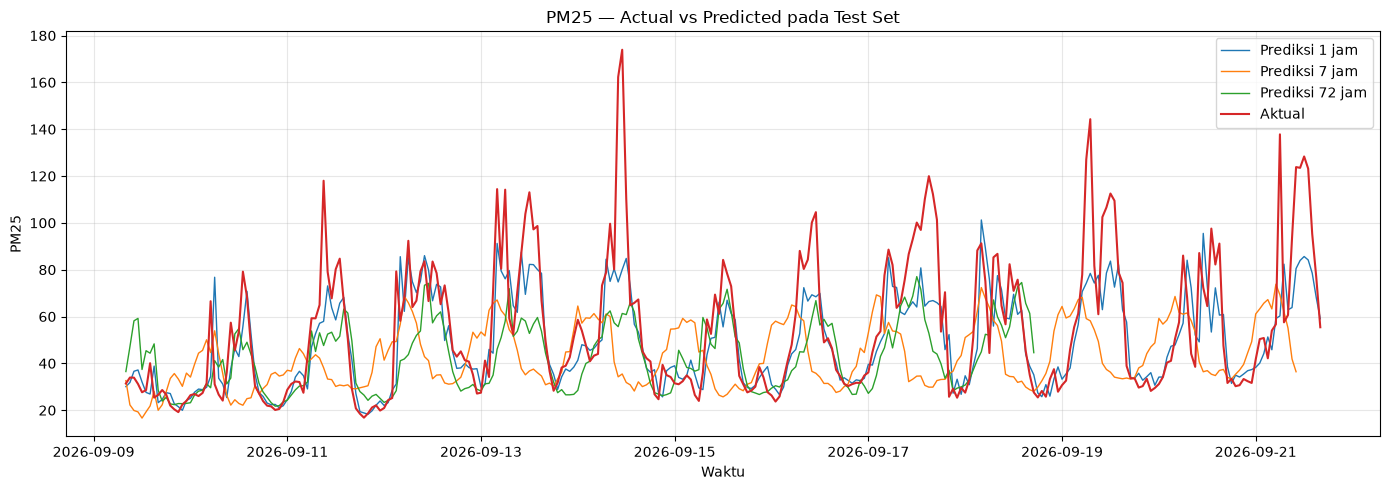

In [295]:
# ============================================================
# 28. ACTUAL VS PREDICTED - PM25
# ============================================================

import matplotlib.pyplot as plt

pollutant = "PM25"

fig, ax = plt.subplots(figsize=(14, 5))

for horizon in [1, 7, 72]:
    target = f"{pollutant}_target_{horizon}h"

    data = final_model_data[target]

    y_test = data["y_test"]
    y_pred = final_models[target].predict(data["X_test"])

    ax.plot(
        y_test.index,
        y_test.values,
        label="Actual",
        linewidth=1.5
    )

    ax.plot(
        y_test.index,
        y_pred,
        label=f"Predicted {horizon}h",
        linewidth=1
    )

    # Satu grafik berisi 3 horizon sekaligus,
    # sehingga tidak perlu membuat 3 plot terpisah.
    break

# Buat ulang dengan struktur yang lebih jelas:
ax.clear()

for horizon in [1, 7, 72]:
    target = f"{pollutant}_target_{horizon}h"

    data = final_model_data[target]

    y_test = data["y_test"]
    y_pred = final_models[target].predict(data["X_test"])

    ax.plot(
        y_test.index,
        y_pred,
        label=f"Prediksi {horizon} jam",
        linewidth=1
    )

# Actual hanya dari horizon 1 sebagai referensi periode test
data_actual = final_model_data["PM25_target_1h"]
ax.plot(
    data_actual["y_test"].index,
    data_actual["y_test"].values,
    label="Aktual",
    linewidth=1.5
)

ax.set_title("PM25 — Actual vs Predicted pada Test Set")
ax.set_xlabel("Waktu")
ax.set_ylabel("PM25")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [296]:
# ============================================================
# 29. CEK INPUT TERAKHIR UNTUK FORECAST
# ============================================================

# Gunakan fitur yang sama dengan saat training
X_forecast = df_model[feature_cols].iloc[[-1]].copy()

print("=== INFORMASI DATA INPUT FORECAST ===\n")

print(f"Timestamp forecast origin : {X_forecast.index[0]}")
print(f"Jumlah fitur              : {X_forecast.shape[1]}")
print(f"Jumlah missing value      : {X_forecast.isna().sum().sum()}")

print("\n=== NILAI FITUR UTAMA ===")

main_features = [
    "PM25",
    "PM10",
    "CO",
    "O3",
    "SO2",
    "NO2",
    "TMP",
    "RAIN",
    "HUM",
    "WS",
    "WD_sin",
    "WD_cos",
]

print(
    X_forecast[main_features].T.to_string(
        header=False
    )
)

print("\n=== STATUS ===")

if X_forecast.isna().sum().sum() == 0:
    print("✓ Semua 58 fitur tersedia. Data siap digunakan untuk forecast.")
else:
    print("✗ Masih terdapat missing value pada fitur forecast.")

=== INFORMASI DATA INPUT FORECAST ===

Timestamp forecast origin : 2026-09-21 17:00:00
Jumlah fitur              : 58
Jumlah missing value      : 0

=== NILAI FITUR UTAMA ===
PM25     55.423392
PM10     99.176302
CO      639.042579
O3       38.541698
SO2       1.771957
NO2      11.193537
TMP      34.011652
RAIN      0.000000
HUM      66.491052
WS        1.391176
WD_sin    0.811716
WD_cos   -0.584052

=== STATUS ===
✓ Semua 58 fitur tersedia. Data siap digunakan untuk forecast.


In [297]:
# ============================================================
# 30. GENERATE FORECAST FINAL
# ============================================================

forecast_rows = []

forecast_origin = X_forecast.index[0]

for pollutant in pollutant_cols:
    for horizon in forecast_horizons:

        target = f"{pollutant}_target_{horizon}h"

        # Ambil model final
        model = final_models[target]

        # Prediksi
        prediction = model.predict(X_forecast)[0]

        # Timestamp hasil forecast
        forecast_time = forecast_origin + pd.Timedelta(hours=horizon)

        forecast_rows.append({
            "forecast_origin": forecast_origin,
            "forecast_time": forecast_time,
            "pollutant": pollutant,
            "horizon_hours": horizon,
            "predicted_value": prediction
        })

forecast_output = pd.DataFrame(forecast_rows)

# Urutkan berdasarkan waktu dan polutan
forecast_output = forecast_output.sort_values(
    ["forecast_time", "pollutant"]
).reset_index(drop=True)

print("=== FORECAST FINAL ===\n")

print(
    forecast_output.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)

print("\nJumlah forecast:", len(forecast_output))

=== FORECAST FINAL ===

    forecast_origin       forecast_time pollutant  horizon_hours  predicted_value
2026-09-21 17:00:00 2026-09-21 18:00:00        CO              1         547.4174
2026-09-21 17:00:00 2026-09-21 18:00:00       NO2              1           9.3930
2026-09-21 17:00:00 2026-09-21 18:00:00        O3              1          43.2255
2026-09-21 17:00:00 2026-09-21 18:00:00      PM10              1          82.6738
2026-09-21 17:00:00 2026-09-21 18:00:00      PM25              1          44.9208
2026-09-21 17:00:00 2026-09-21 18:00:00       SO2              1           2.0408
2026-09-21 17:00:00 2026-09-21 19:00:00        CO              2         475.2704
2026-09-21 17:00:00 2026-09-21 19:00:00       NO2              2           9.9084
2026-09-21 17:00:00 2026-09-21 19:00:00        O3              2          44.8120
2026-09-21 17:00:00 2026-09-21 19:00:00      PM10              2          66.7606
2026-09-21 17:00:00 2026-09-21 19:00:00      PM25              2          

In [298]:
# ============================================================
# 31. SANITY CHECK FORECAST FINAL
# ============================================================

print("=== SANITY CHECK FORECAST ===\n")

# 1. Jumlah baris
print(f"Jumlah forecast              : {len(forecast_output)}")
print(f"Jumlah yang diharapkan       : {len(pollutant_cols) * len(forecast_horizons)}")

# 2. Missing value
missing_forecast = forecast_output["predicted_value"].isna().sum()
print(f"Missing prediction           : {missing_forecast}")

# 3. Nilai negatif
negative_forecast = (
    forecast_output["predicted_value"] < 0
).sum()
print(f"Prediksi bernilai negatif    : {negative_forecast}")

# 4. Duplicate forecast
duplicate_forecast = forecast_output.duplicated(
    subset=["forecast_time", "pollutant"]
).sum()
print(f"Duplicate forecast           : {duplicate_forecast}")

# 5. Rentang nilai
print("\n=== RENTANG HASIL FORECAST ===")

forecast_range = (
    forecast_output
    .groupby("pollutant")["predicted_value"]
    .agg(["min", "max"])
    .reset_index()
)

print(
    forecast_range.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)

# 6. Status akhir
print("\n=== STATUS ===")

if (
    len(forecast_output) == len(pollutant_cols) * len(forecast_horizons)
    and missing_forecast == 0
    and negative_forecast == 0
    and duplicate_forecast == 0
):
    print("✓ Forecast final lolos sanity check.")
else:
    print("⚠ Terdapat hal yang perlu diperiksa.")

=== SANITY CHECK FORECAST ===

Jumlah forecast              : 48
Jumlah yang diharapkan       : 48
Missing prediction           : 0
Prediksi bernilai negatif    : 0
Duplicate forecast           : 0

=== RENTANG HASIL FORECAST ===
pollutant      min      max
       CO 445.8912 556.3448
      NO2   9.3930  18.7129
       O3  29.1477  46.6718
     PM10  61.9990  86.4191
     PM25  31.6515  44.9208
      SO2   1.6767   3.5701

=== STATUS ===
✓ Forecast final lolos sanity check.


In [299]:
# ============================================================
# 32. FORMAT OUTPUT FORECAST FINAL
# ============================================================

forecast_final = (
    forecast_output
    .pivot_table(
        index=["forecast_origin", "forecast_time", "horizon_hours"],
        columns="pollutant",
        values="predicted_value"
    )
    .reset_index()
)

# Hilangkan nama index kolom hasil pivot
forecast_final.columns.name = None

# Urutkan kolom
forecast_final = forecast_final[
    [
        "forecast_origin",
        "forecast_time",
        "horizon_hours",
        "PM25",
        "PM10",
        "CO",
        "O3",
        "SO2",
        "NO2"
    ]
].sort_values("forecast_time").reset_index(drop=True)

print("=== FORECAST FINAL UNTUK OUTPUT ===\n")

print(
    forecast_final.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)

print(f"\nJumlah baris : {len(forecast_final)}")
print(f"Jumlah kolom : {len(forecast_final.columns)}")

=== FORECAST FINAL UNTUK OUTPUT ===

    forecast_origin       forecast_time  horizon_hours    PM25    PM10       CO      O3    SO2     NO2
2026-09-21 17:00:00 2026-09-21 18:00:00              1 44.9208 82.6738 547.4174 43.2255 2.0408  9.3930
2026-09-21 17:00:00 2026-09-21 19:00:00              2 36.8053 66.7606 475.2704 44.8120 1.8647  9.9084
2026-09-21 17:00:00 2026-09-21 20:00:00              3 35.9050 67.6071 456.1122 46.6718 2.0857 11.3334
2026-09-21 17:00:00 2026-09-21 21:00:00              4 35.7420 65.2205 445.8912 46.5971 2.0026 12.0348
2026-09-21 17:00:00 2026-09-21 22:00:00              5 34.5905 66.0669 473.1345 45.3329 1.8391 14.4341
2026-09-21 17:00:00 2026-09-21 23:00:00              6 31.6515 63.4026 452.9490 42.3568 1.6767 14.9993
2026-09-21 17:00:00 2026-09-22 00:00:00              7 32.9424 61.9990 480.6006 39.5275 1.6816 18.7129
2026-09-21 17:00:00 2026-09-24 17:00:00             72 43.5702 86.4191 556.3448 29.1477 3.5701 13.0546

Jumlah baris : 8
Jumlah kolom : 9


In [300]:
# ============================================================
# 33. SIMPAN FORECAST FINAL KE CSV
# ============================================================

from pathlib import Path

output_dir = Path("../outputs/forecast")
output_dir.mkdir(parents=True, exist_ok=True)

output_path = output_dir / "forecast_ispu_rf_final.csv"

forecast_final.to_csv(
    output_path,
    index=False
)

print("=== FORECAST BERHASIL DISIMPAN ===")
print(f"File : {output_path.resolve()}")

print("\nUkuran file:")
print(forecast_final.shape)

print("\nPreview:")
print(forecast_final)

=== FORECAST BERHASIL DISIMPAN ===
File : D:\Kuliah\KP\forecast-ispu\outputs\forecast\forecast_ispu_rf_final.csv

Ukuran file:
(8, 9)

Preview:
      forecast_origin       forecast_time  horizon_hours       PM25  \
0 2026-09-21 17:00:00 2026-09-21 18:00:00              1  44.920760   
1 2026-09-21 17:00:00 2026-09-21 19:00:00              2  36.805267   
2 2026-09-21 17:00:00 2026-09-21 20:00:00              3  35.905042   
3 2026-09-21 17:00:00 2026-09-21 21:00:00              4  35.741991   
4 2026-09-21 17:00:00 2026-09-21 22:00:00              5  34.590545   
5 2026-09-21 17:00:00 2026-09-21 23:00:00              6  31.651487   
6 2026-09-21 17:00:00 2026-09-22 00:00:00              7  32.942356   
7 2026-09-21 17:00:00 2026-09-24 17:00:00             72  43.570191   

        PM10          CO         O3       SO2        NO2  
0  82.673836  547.417447  43.225508  2.040820   9.393011  
1  66.760555  475.270383  44.812001  1.864723   9.908368  
2  67.607054  456.112203  46.671835  2.

In [301]:
# ============================================================
# 34. SIMPAN MODEL RANDOM FOREST FINAL
# ============================================================

import joblib
from pathlib import Path

# Folder khusus untuk model forecasting Random Forest
model_dir = Path("../models/forecast_RF_model")
model_dir.mkdir(parents=True, exist_ok=True)

saved_models = []

for target, model in final_models.items():

    model_path = model_dir / f"RF_{target}.joblib"

    joblib.dump(
        model,
        model_path
    )

    saved_models.append(model_path)

print("=== MODEL RANDOM FOREST BERHASIL DISIMPAN ===\n")

print(f"Folder model : {model_dir.resolve()}")
print(f"Jumlah model : {len(saved_models)}")

print("\nDaftar model:")

for path in saved_models:
    print(f"✓ {path.name}")

=== MODEL RANDOM FOREST BERHASIL DISIMPAN ===

Folder model : D:\Kuliah\KP\forecast-ispu\models\forecast_RF_model
Jumlah model : 48

Daftar model:
✓ RF_PM25_target_1h.joblib
✓ RF_PM25_target_2h.joblib
✓ RF_PM25_target_3h.joblib
✓ RF_PM25_target_4h.joblib
✓ RF_PM25_target_5h.joblib
✓ RF_PM25_target_6h.joblib
✓ RF_PM25_target_7h.joblib
✓ RF_PM25_target_72h.joblib
✓ RF_PM10_target_1h.joblib
✓ RF_PM10_target_2h.joblib
✓ RF_PM10_target_3h.joblib
✓ RF_PM10_target_4h.joblib
✓ RF_PM10_target_5h.joblib
✓ RF_PM10_target_6h.joblib
✓ RF_PM10_target_7h.joblib
✓ RF_PM10_target_72h.joblib
✓ RF_CO_target_1h.joblib
✓ RF_CO_target_2h.joblib
✓ RF_CO_target_3h.joblib
✓ RF_CO_target_4h.joblib
✓ RF_CO_target_5h.joblib
✓ RF_CO_target_6h.joblib
✓ RF_CO_target_7h.joblib
✓ RF_CO_target_72h.joblib
✓ RF_O3_target_1h.joblib
✓ RF_O3_target_2h.joblib
✓ RF_O3_target_3h.joblib
✓ RF_O3_target_4h.joblib
✓ RF_O3_target_5h.joblib
✓ RF_O3_target_6h.joblib
✓ RF_O3_target_7h.joblib
✓ RF_O3_target_72h.joblib
✓ RF_SO2_target_1

In [302]:
# ============================================================
# 35. VERIFIKASI MODEL RANDOM FOREST YANG TERSIMPAN
# ============================================================




# Path folder model
model_dir = Path("../models/forecast_RF_model")

# Pilih satu model sebagai sampel
test_target = "PM25_target_1h"

model_path = model_dir / f"RF_{test_target}.joblib"

print("=== VERIFIKASI MODEL TERSIMPAN ===\n")
print(f"Model yang diuji : {test_target}")
print(f"Path             : {model_path}")

# Load model dari file
loaded_model = joblib.load(model_path)

# Prediksi dari model yang masih ada di memory
prediction_memory = final_models[test_target].predict(X_forecast)[0]

# Prediksi dari model yang sudah di-load dari file
prediction_loaded = loaded_model.predict(X_forecast)[0]

print("\n=== HASIL PREDIKSI ===")
print(f"Prediksi model memory : {prediction_memory:.10f}")
print(f"Prediksi model loaded : {prediction_loaded:.10f}")

# Bandingkan
difference = abs(prediction_memory - prediction_loaded)

print(f"\nSelisih prediksi       : {difference:.10f}")

if difference < 1e-10:
    print("\n✓ VERIFIKASI BERHASIL")
    print("Model yang tersimpan menghasilkan prediksi yang sama.")
else:
    print("\n⚠ TERDAPAT PERBEDAAN")
    print("Periksa kembali proses penyimpanan model.")

=== VERIFIKASI MODEL TERSIMPAN ===

Model yang diuji : PM25_target_1h
Path             : ..\models\forecast_RF_model\RF_PM25_target_1h.joblib

=== HASIL PREDIKSI ===
Prediksi model memory : 44.9207600920
Prediksi model loaded : 44.9207600920

Selisih prediksi       : 0.0000000000

✓ VERIFIKASI BERHASIL
Model yang tersimpan menghasilkan prediksi yang sama.


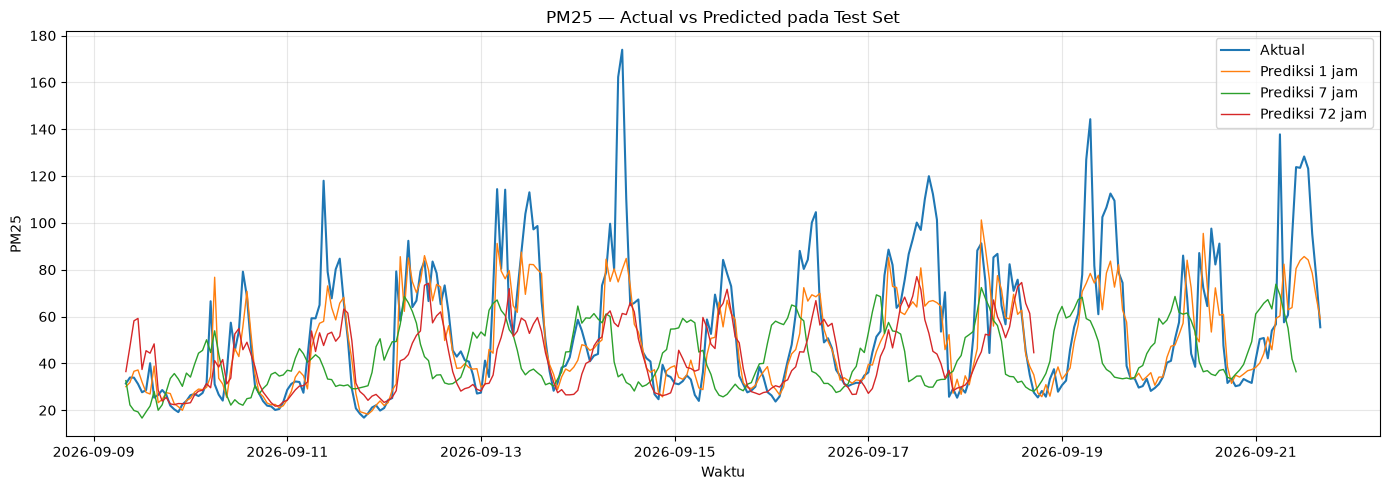

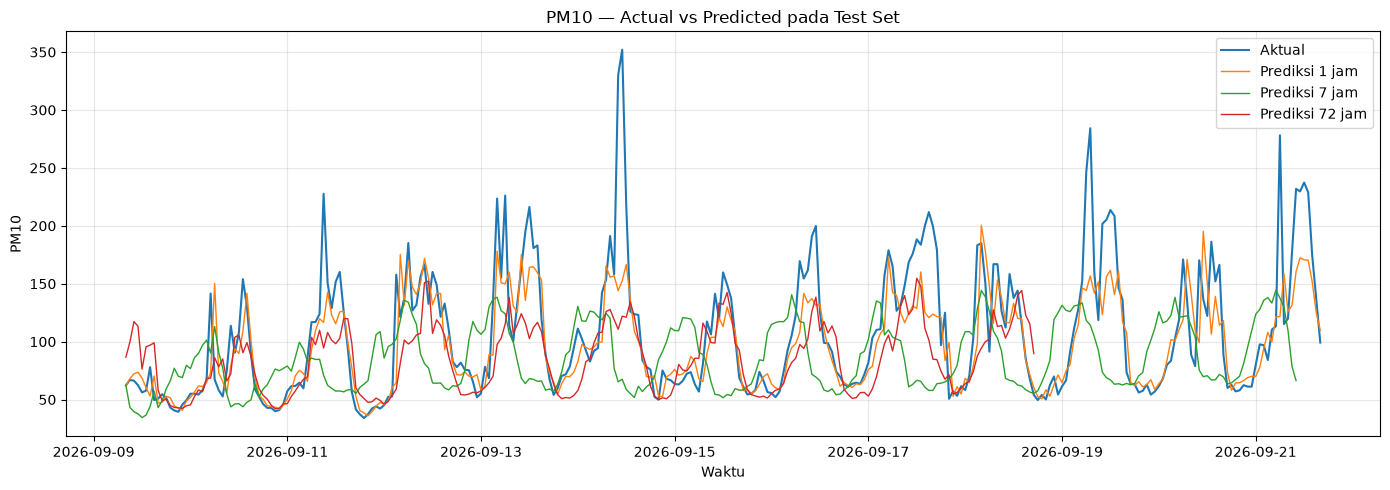

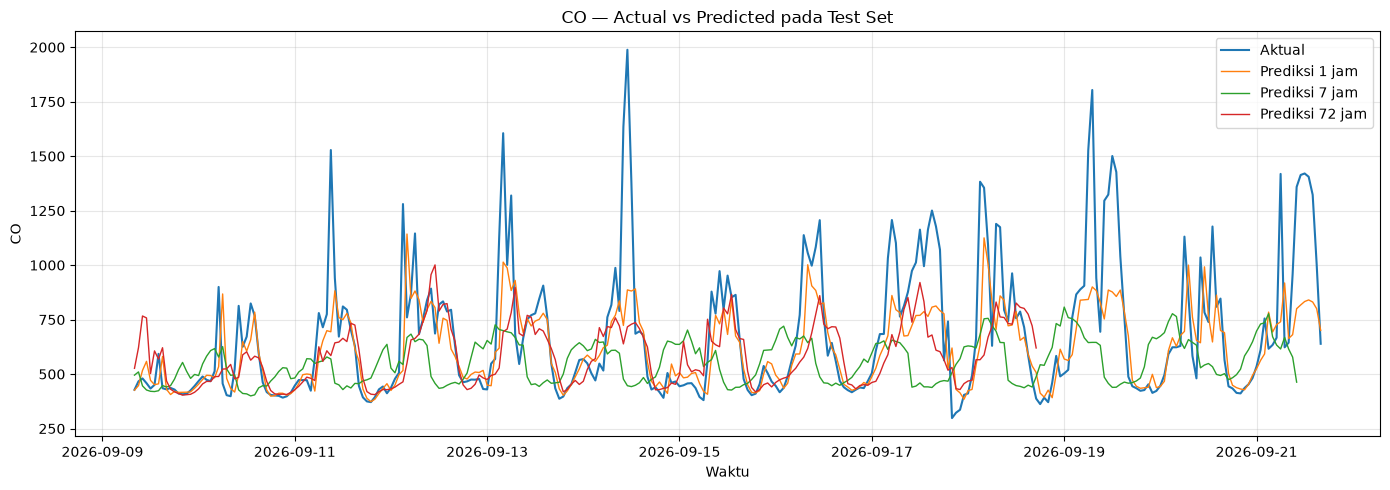

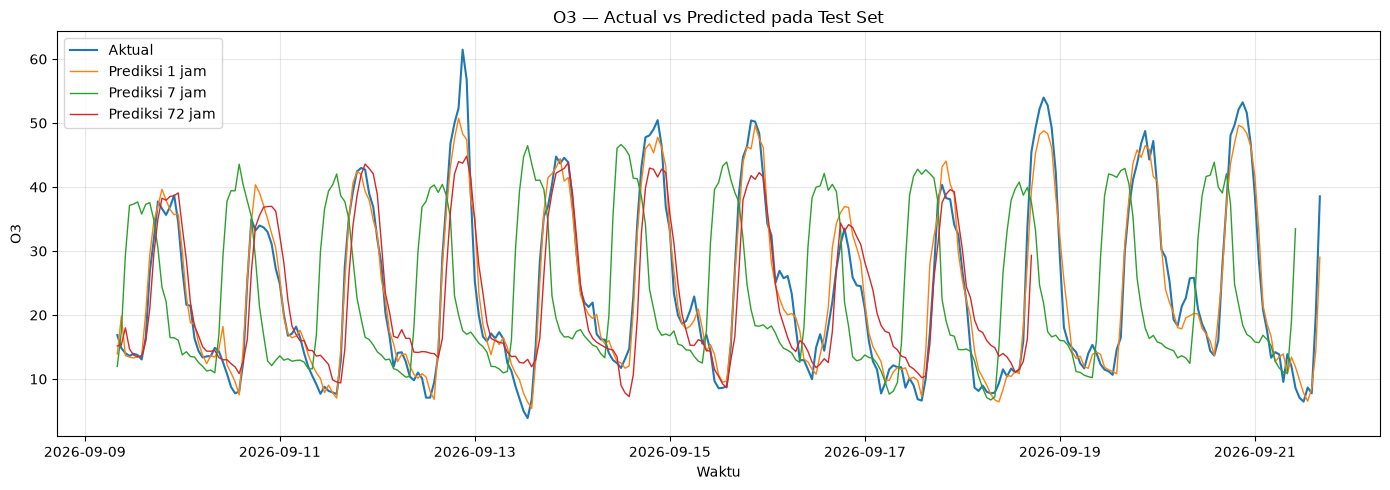

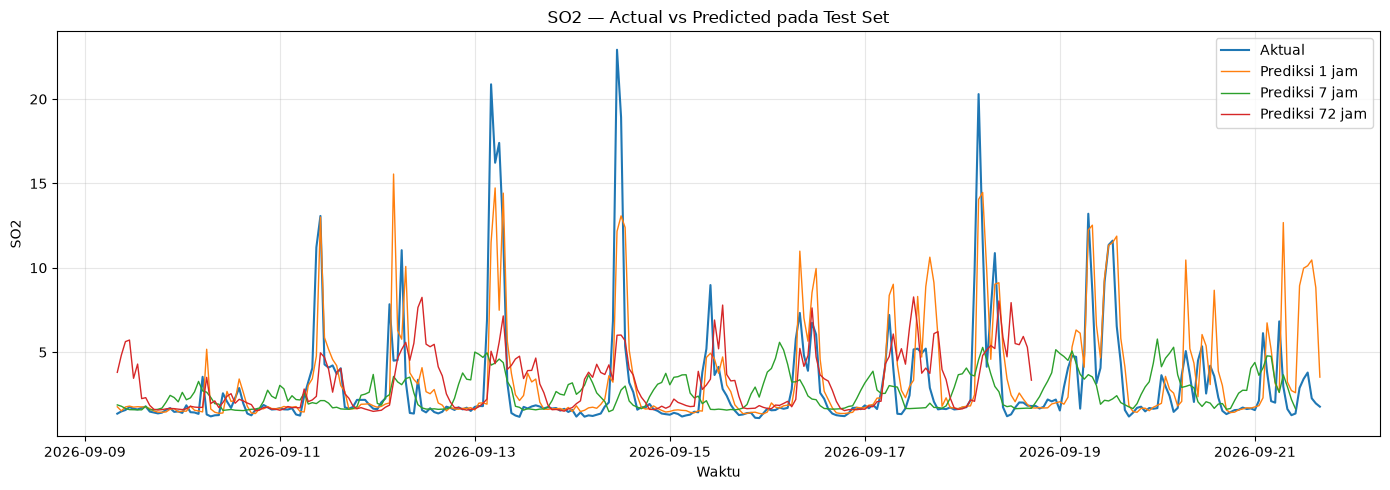

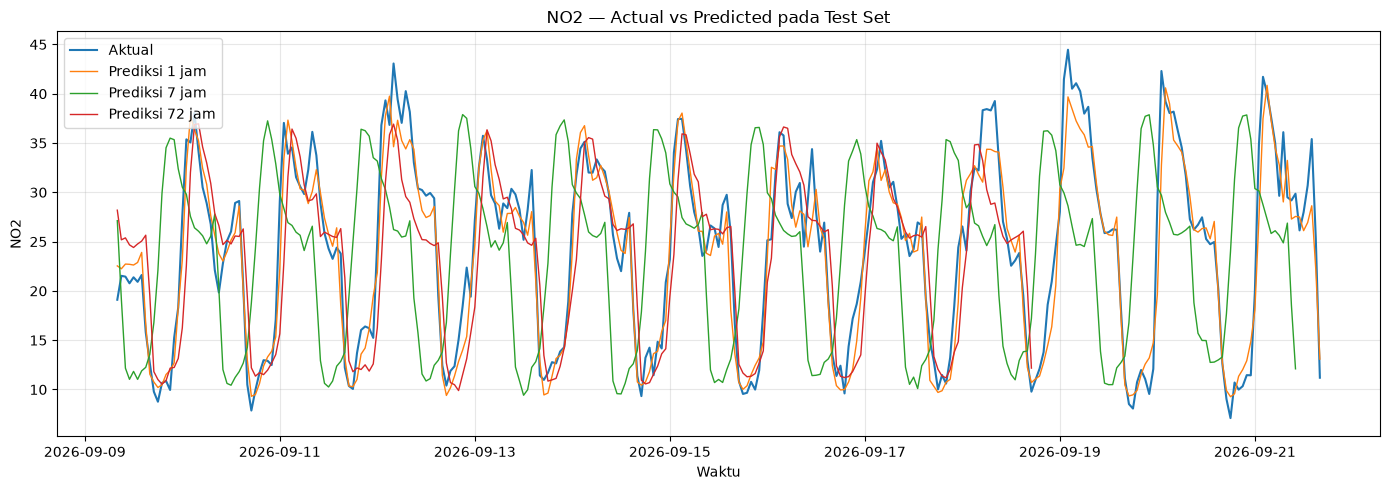

In [303]:
# ============================================================
# 36. ACTUAL VS PREDICTED - SEMUA POLUTAN
# ============================================================

import matplotlib.pyplot as plt

# Horizon yang divisualisasikan
plot_horizons = [1, 7, 72]

# Semua polutan
plot_pollutants = ["PM25", "PM10", "CO", "O3", "SO2", "NO2"]

for pollutant in plot_pollutants:

    fig, ax = plt.subplots(figsize=(14, 5))

    # Actual menggunakan target 1 jam sebagai referensi
    actual_target = f"{pollutant}_target_1h"
    actual_data = final_model_data[actual_target]

    ax.plot(
        actual_data["y_test"].index,
        actual_data["y_test"].values,
        label="Aktual",
        linewidth=1.5
    )

    # Prediksi untuk horizon 1h, 7h, dan 72h
    for horizon in plot_horizons:

        target = f"{pollutant}_target_{horizon}h"

        data = final_model_data[target]

        y_pred = final_models[target].predict(
            data["X_test"]
        )

        ax.plot(
            data["y_test"].index,
            y_pred,
            label=f"Prediksi {horizon} jam",
            linewidth=1
        )

    ax.set_title(
        f"{pollutant} — Actual vs Predicted pada Test Set"
    )

    ax.set_xlabel("Waktu")
    ax.set_ylabel(pollutant)

    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

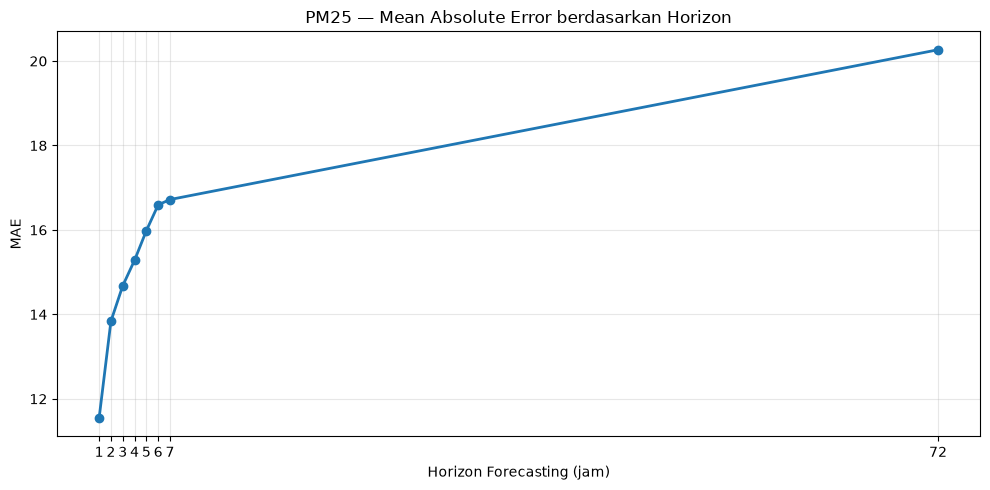

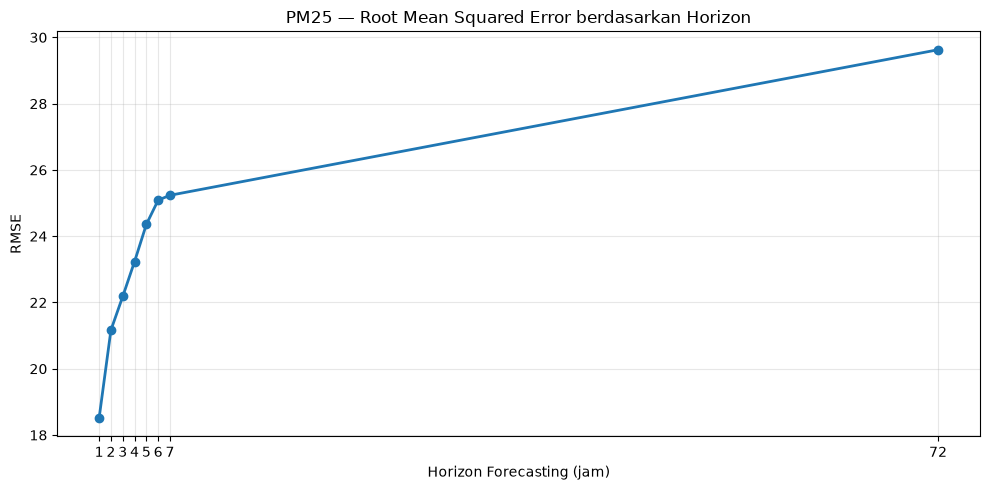

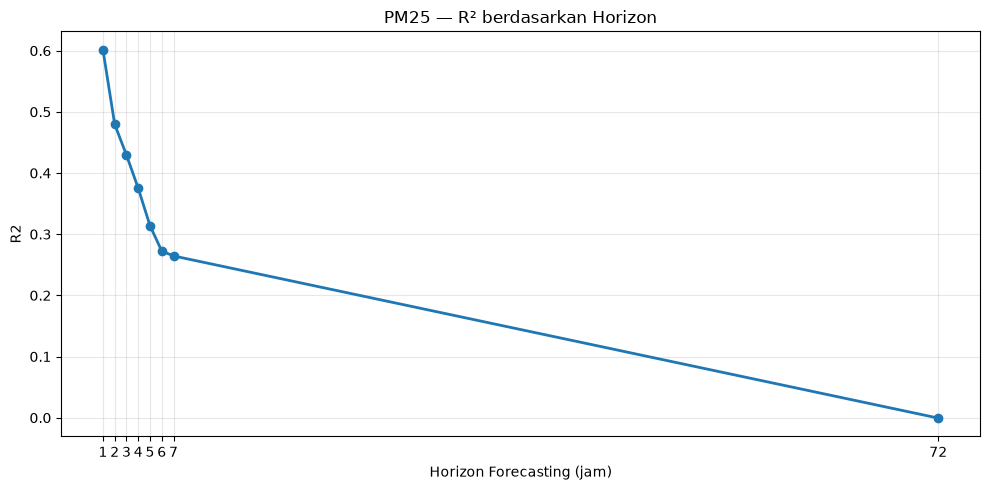

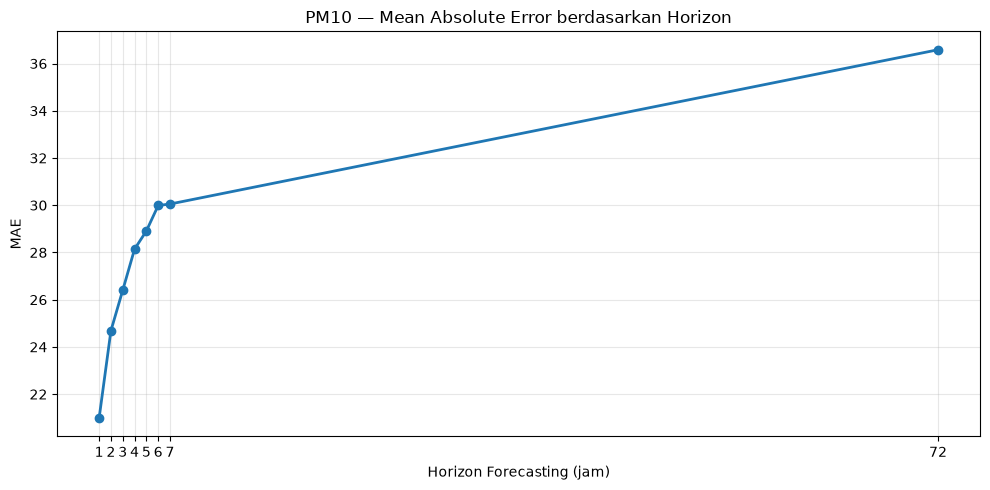

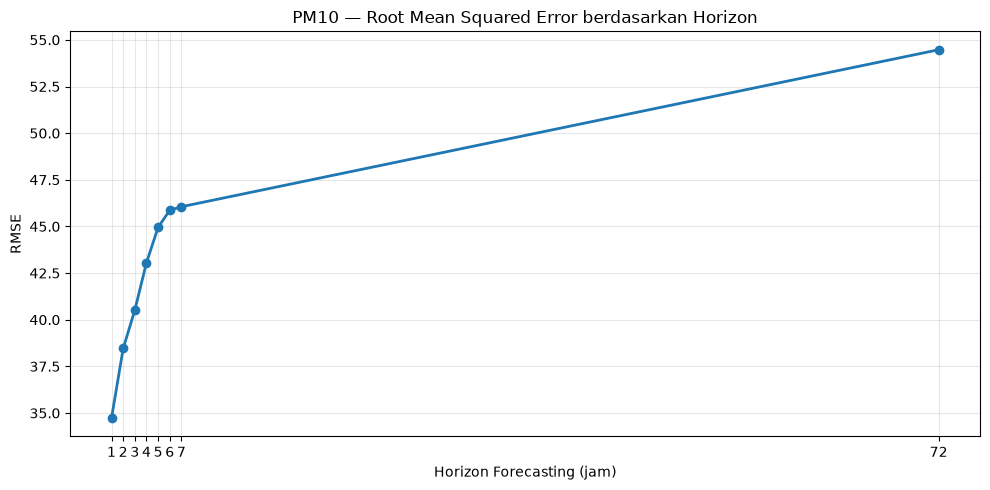

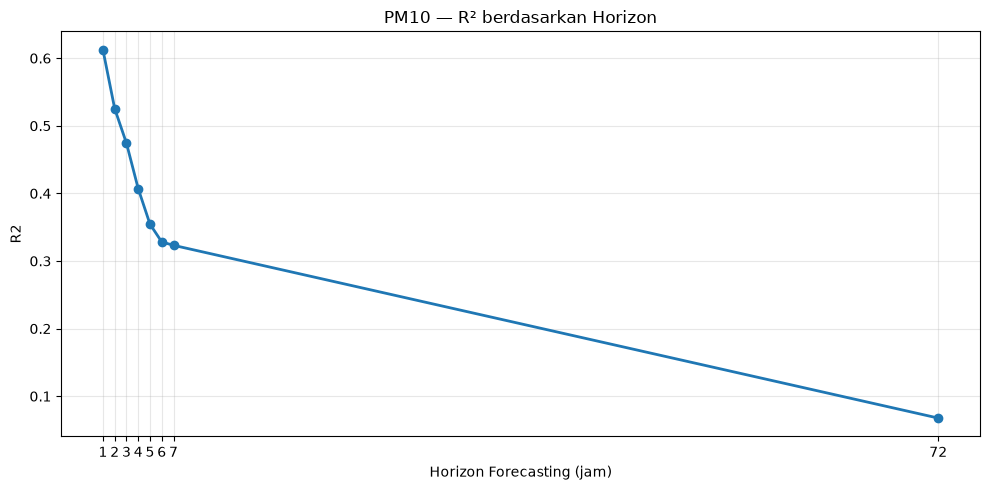

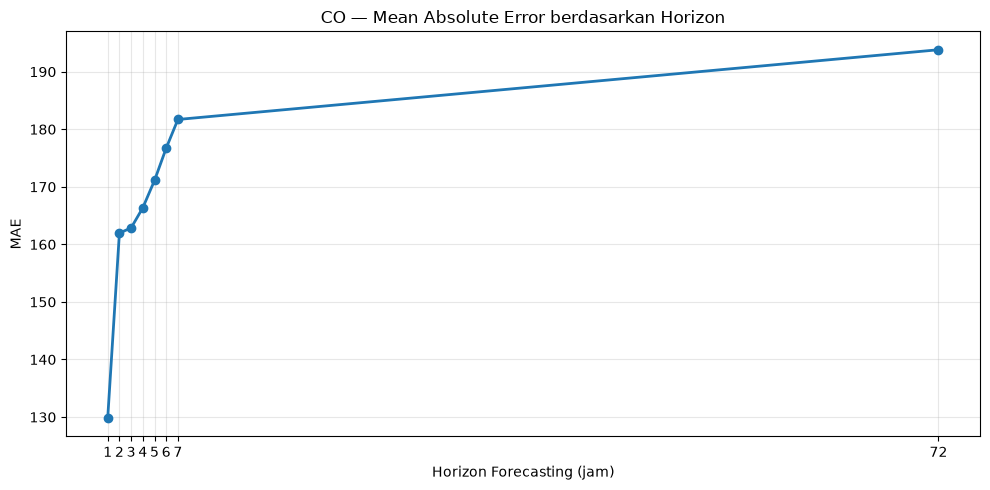

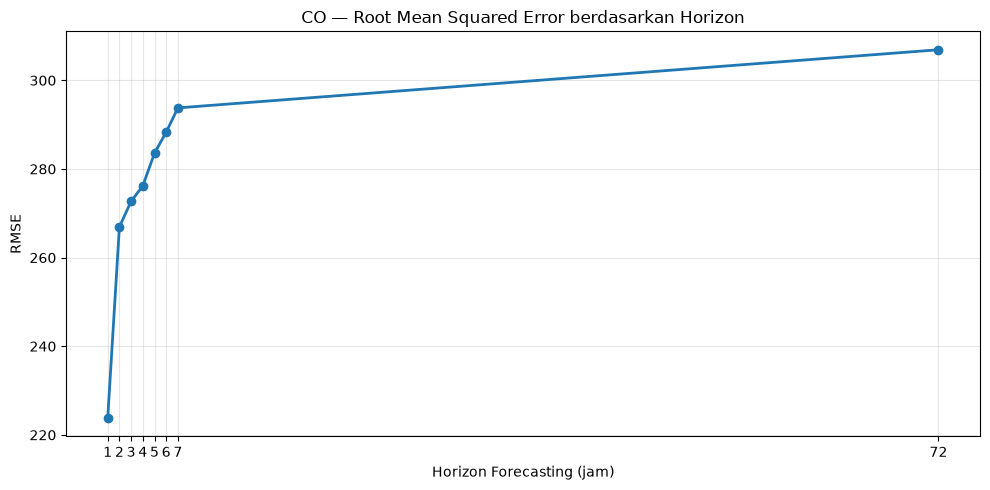

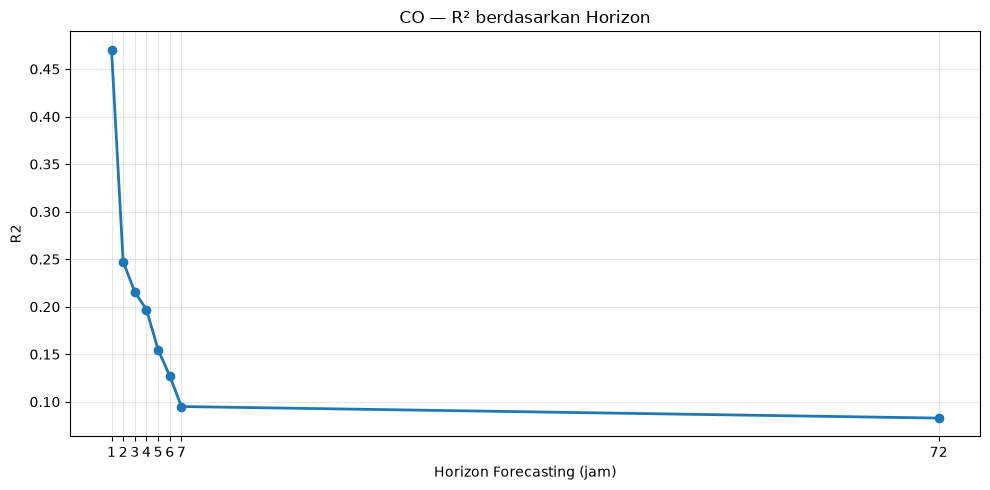

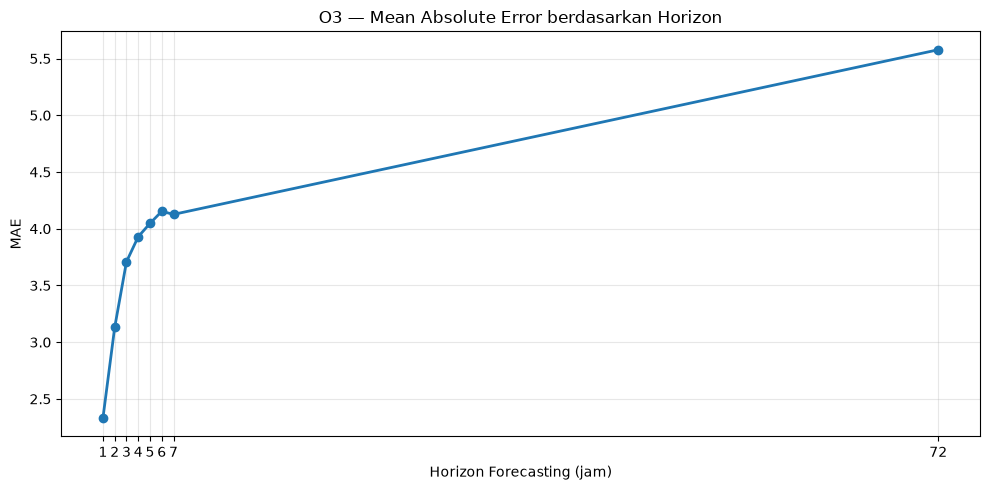

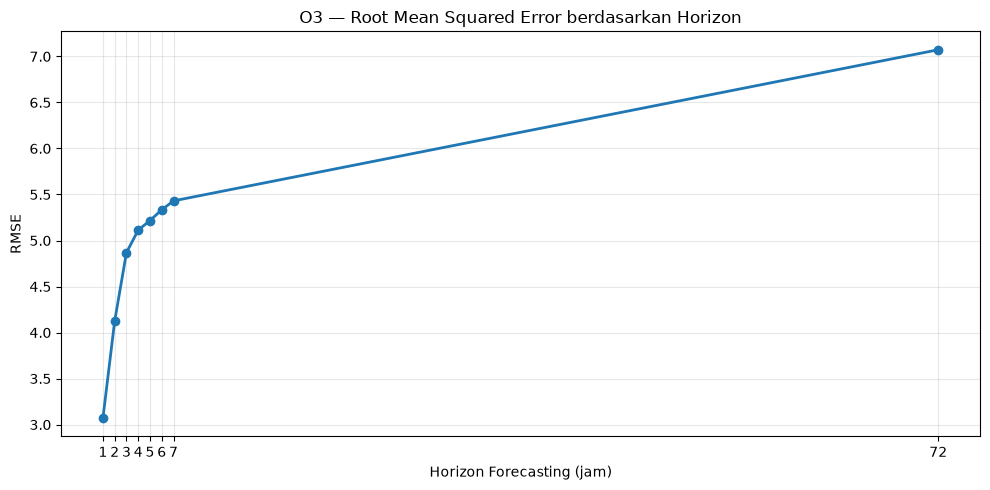

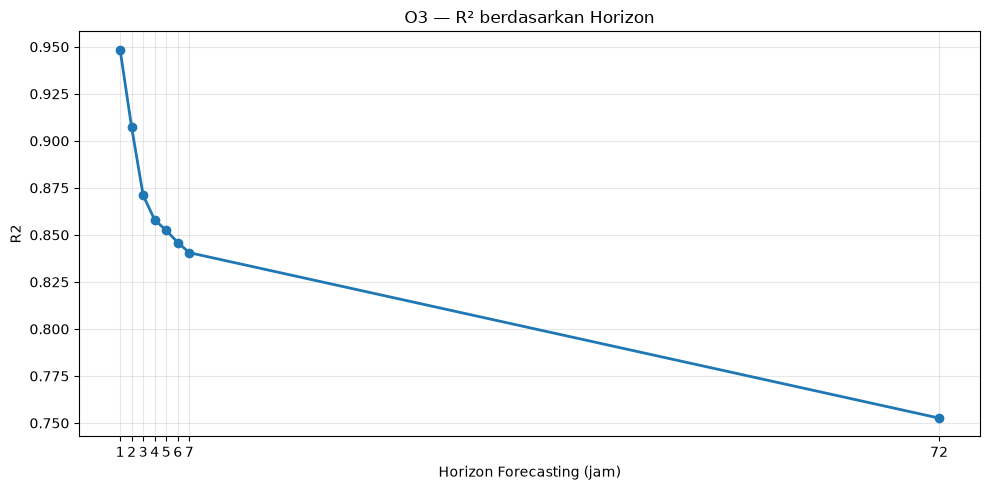

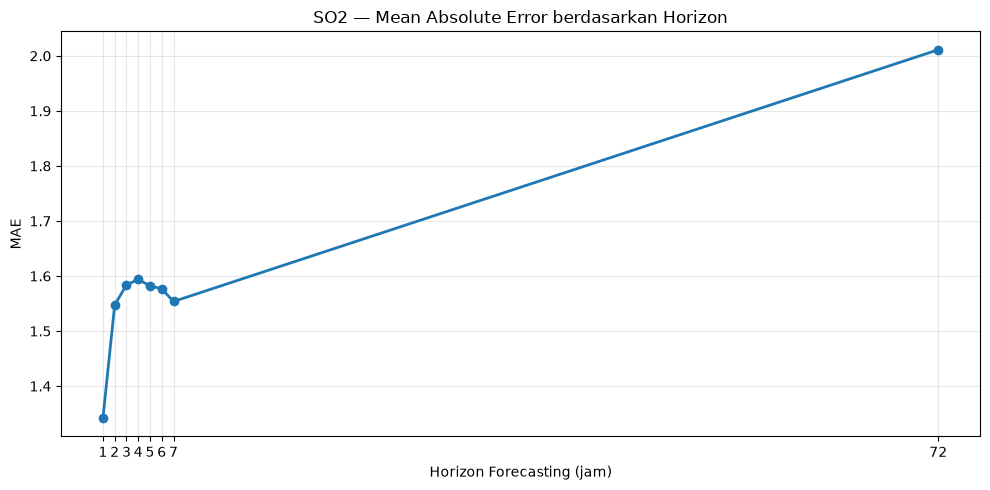

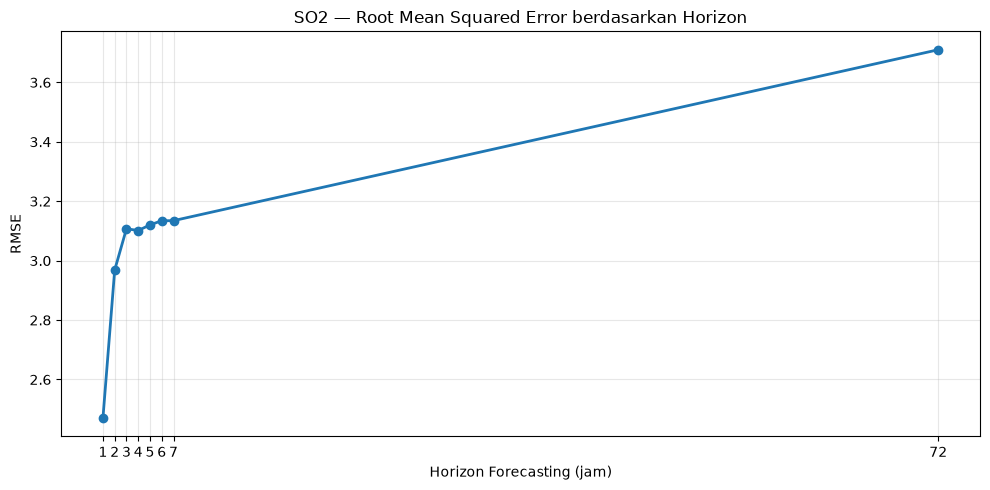

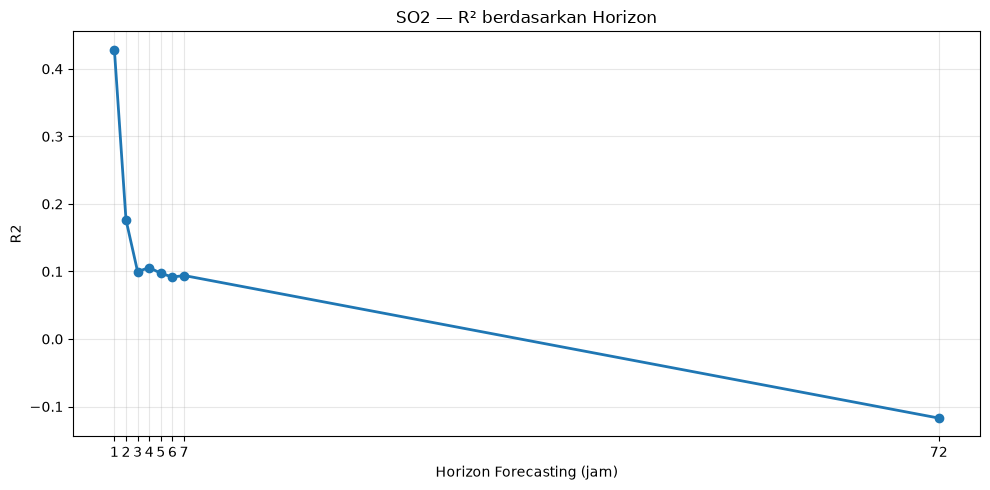

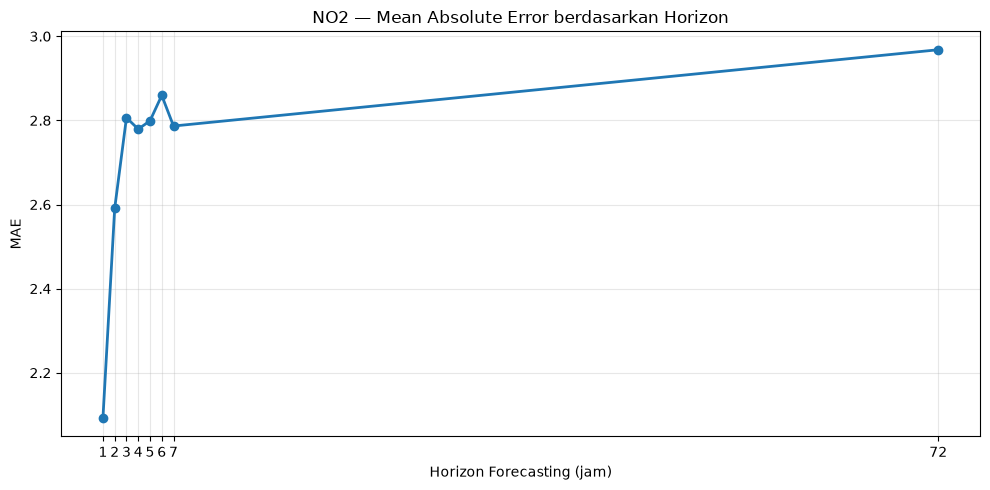

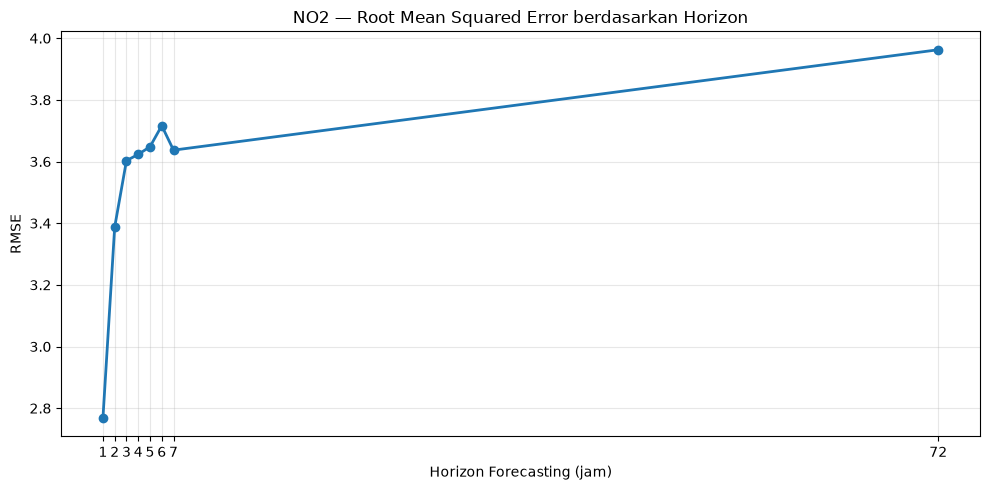

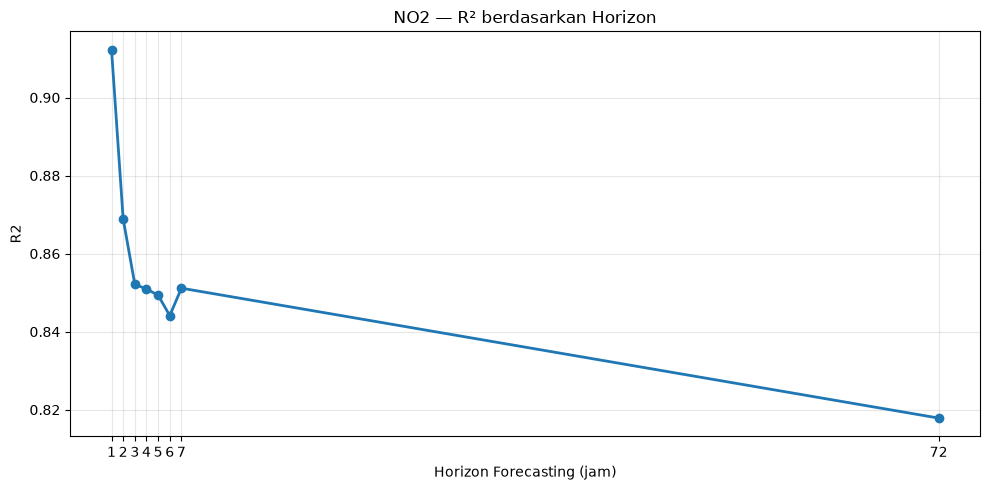

In [304]:
# ============================================================
# 37. VISUALISASI MAE, RMSE, DAN R²
#     SEMUA POLUTAN DAN SEMUA HORIZON
# ============================================================



plot_pollutants = ["PM25", "PM10", "CO", "O3", "SO2", "NO2"]

metrics = [
    ("MAE", "MAE", "Mean Absolute Error"),
    ("RMSE", "RMSE", "Root Mean Squared Error"),
    ("R2", "R2", "R²")
]

for pollutant in plot_pollutants:

    pollutant_data = test_summary[
        test_summary["pollutant"] == pollutant
    ].sort_values("horizon")

    for metric_col, metric_label, metric_title in metrics:

        fig, ax = plt.subplots(figsize=(10, 5))

        ax.plot(
            pollutant_data["horizon"],
            pollutant_data[metric_col],
            marker="o",
            linewidth=2
        )

        ax.set_title(
            f"{pollutant} — {metric_title} berdasarkan Horizon"
        )

        ax.set_xlabel("Horizon Forecasting (jam)")
        ax.set_ylabel(metric_label)

        ax.set_xticks(
            pollutant_data["horizon"]
        )

        ax.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()